In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!pip install ultralytics
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt
import os

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Aug  8 20:38:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [ ]:
import os
os.listdir('/content/gdrive')

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']

CONVERT VIDEOS TO FRAMES

In [ ]:
output_folder = '/content/gdrive/MyDrive/frames/v18_frames'
os.makedirs(output_folder, exist_ok=True)
!ffmpeg -i "/content/gdrive/MyDrive/frames/v18.mp4" -ss 00:01:15 -to 00:04:10 -vf fps=5 "/content/gdrive/MyDrive/frames/v18_frames/frame_%04d.jpg"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Renaming frames

In [ ]:
import os

folder = "/content/gdrive/MyDrive/frames/v15_frames/" #folder that need to rename

files = sorted(os.listdir(folder))

for i, file in enumerate(files):
    old_path = os.path.join(folder, file)

    # skip non-image files just in case
    if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    new_name = f"frame_{i+1:04d}.jpg"
    new_path = os.path.join(folder, new_name)

    os.rename(old_path, new_path)

print("Renaming complete ✅")

Renaming complete ✅


In [ ]:
import shutil

folder_to_zip = "/content/gdrive/MyDrive/frames/v15_frames/" # zip frames
zip_output = "/content/gdrive/MyDrive/frames/v15_zip"

shutil.make_archive(zip_output, 'zip', folder_to_zip)

print("ZIP file created ✅")

ZIP file created ✅


Combine all images and labels

In [ ]:
import os
import shutil
from pathlib import Path

# Your dataset folders
datasets = {
    "v1": "/content/gdrive/MyDrive/frames/v1/images",
    "v2": "/content/gdrive/MyDrive/frames/v2/images",
    "v3": "/content/gdrive/MyDrive/frames/v3/images",
    "v5": "/content/gdrive/MyDrive/frames/v5/images",
    "v6": "/content/gdrive/MyDrive/frames/v6/images",
    "v7": "/content/gdrive/MyDrive/frames/v7/images",
    "v8": "/content/gdrive/MyDrive/frames/v8/images",
    "v9": "/content/gdrive/MyDrive/frames/v9/images",
    "v10": "/content/gdrive/MyDrive/frames/v10/images",
    "v11": "/content/gdrive/MyDrive/frames/v11/images",
    "v12": "/content/gdrive/MyDrive/frames/v12/images",
    "v13": "/content/gdrive/MyDrive/frames/v13/images",
    "v14": "/content/gdrive/MyDrive/frames/v14/images",
    "v15": "/content/gdrive/MyDrive/frames/v15/images",
}

# Output folder
output_images = Path("/content/gdrive/MyDrive/combined_dataset/all_images")
output_images.mkdir(parents=True, exist_ok=True)

image_exts = [".jpg", ".jpeg", ".png"]

for prefix, dataset_path in datasets.items():

    dataset_path = Path(dataset_path)

    # Check if the source dataset directory exists
    if not dataset_path.is_dir():
        print(f"Warning: Dataset directory '{dataset_path}' not found. Skipping.")
        continue

    for img_file in dataset_path.glob("*"):

        if img_file.suffix.lower() not in image_exts:
            continue

        # Explicitly check if the source file exists before copying
        if not img_file.is_file():
            print(f"Warning: Source file '{img_file}' not found or is not a regular file. Skipping.")
            continue

        new_name = f"{prefix}_{img_file.name}"

        shutil.copy(
            img_file,
            output_images / new_name
        )

print("Images combined successfully!")
print("Total images:", len(list(output_images.iterdir())))


Images combined successfully!
Total images: 1127


In [ ]:
import os
import shutil
from pathlib import Path

datasets = {
    "v1": "/content/gdrive/MyDrive/frames/v1/labels/train",
    "v2": "/content/gdrive/MyDrive/frames/v2/labels/train",
    "v3": "/content/gdrive/MyDrive/frames/v3/labels/train",
    "v5": "/content/gdrive/MyDrive/frames/v5/labels/train",
    "v6": "/content/gdrive/MyDrive/frames/v6/labels/train",
    "v7": "/content/gdrive/MyDrive/frames/v7/labels/train",
    "v8": "/content/gdrive/MyDrive/frames/v8/labels/train",
    "v9": "/content/gdrive/MyDrive/frames/v9/labels/train",
    "v10": "/content/gdrive/MyDrive/frames/v10/labels/train",
    "v11": "/content/gdrive/MyDrive/frames/v11/labels/train",
    "v12": "/content/gdrive/MyDrive/frames/v12/labels/train",
    "v13": "/content/gdrive/MyDrive/frames/v13/labels/train",
    "v14": "/content/gdrive/MyDrive/frames/v14/labels/train",
    "v15": "/content/gdrive/MyDrive/frames/v15/labels/train",
}

output_labels = Path("/content/gdrive/MyDrive/combined_dataset/all_labels")
output_labels.mkdir(parents=True, exist_ok=True)

for prefix, dataset_path in datasets.items():

    dataset_path = Path(dataset_path)

    for label_file in dataset_path.glob("*.txt"):

        new_name = f"{prefix}_{label_file.name}"

        shutil.copy(
            label_file,
            output_labels / new_name
        )

print("Labels combined successfully!")
print("Total labels:", len(list(output_labels.iterdir())))

Labels combined successfully!
Total labels: 1127


In [ ]:
from pathlib import Path
import shutil
import random
import os

combined_dir = Path("/content/gdrive/MyDrive/combined_dataset")

all_images = combined_dir / "all_images"
all_labels = combined_dir / "all_labels"

final_dir = Path("/content/gdrive/MyDrive/combined_dataset/final_yolo_dataset")

for split in ["train", "val"]:
    (final_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (final_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

# keep only images that have matching labels
image_exts = [".jpg", ".jpeg", ".png"]

matched_images = []

for img in all_images.iterdir():
    if img.suffix.lower() not in image_exts:
        continue

    label = all_labels / f"{img.stem}.txt"

    if label.exists():
        matched_images.append(img)
    else:
        print("No label found for:", img.name)

print("Matched images:", len(matched_images))

Matched images: 1127


# TEST SPLIT VALIDATION

In [ ]:
import shutil
from pathlib import Path

# Combined folders
all_images = Path(
    "/content/gdrive/MyDrive/combined_dataset/all_images"
)

all_labels = Path(
    "/content/gdrive/MyDrive/combined_dataset/all_labels"
)

# Final detection dataset
final_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/entry_exit_detection"
)


if final_dir.exists():
    shutil.rmtree(final_dir)

# Dataset-level split
train_datasets = {
    "v1", "v2", "v3", "v5", "v6",
    "v7", "v8", "v9", "v10", "v11"
}

val_datasets = {
    "v12", "v13"
}

test_datasets = {
    "v14", "v15"
}

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}


def get_dataset_prefix(image_path):
    """
    Example:
    v12_frame_0001.jpg -> v12
    """
    return image_path.stem.split("_")[0].lower()


def copy_split(images, split_name):
    destination_images = final_dir / "images" / split_name
    destination_labels = final_dir / "labels" / split_name

    destination_images.mkdir(parents=True, exist_ok=True)
    destination_labels.mkdir(parents=True, exist_ok=True)

    copied = 0

    for image_path in images:
        label_path = all_labels / f"{image_path.stem}.txt"

        if not label_path.exists():
            print(
                f"Warning: No label found for {image_path.name}"
            )
            continue

        shutil.copy2(
            image_path,
            destination_images / image_path.name
        )

        shutil.copy2(
            label_path,
            destination_labels / label_path.name
        )

        copied += 1

    print(f"{split_name}: copied {copied} image-label pairs")


# Find all valid image-label pairs
matched_images = []

for image_path in sorted(all_images.iterdir()):

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in image_extensions:
        continue

    label_path = all_labels / f"{image_path.stem}.txt"

    if label_path.exists():
        matched_images.append(image_path)
    else:
        print(f"Missing label: {image_path.name}")


# Assign entire datasets to one split
train_images = []
val_images = []
test_images = []
unknown_images = []

for image_path in matched_images:
    dataset_prefix = get_dataset_prefix(image_path)

    if dataset_prefix in train_datasets:
        train_images.append(image_path)

    elif dataset_prefix in val_datasets:
        val_images.append(image_path)

    elif dataset_prefix in test_datasets:
        test_images.append(image_path)

    else:
        unknown_images.append(image_path)


copy_split(train_images, "train")
copy_split(val_images, "val")
copy_split(test_images, "test")

print("\nDataset summary")
print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))
print("Unknown:", len(unknown_images))

if unknown_images:
    print("\nUnknown dataset prefixes:")
    for image_path in unknown_images[:20]:
        print(image_path.name)

train: copied 729 image-label pairs
val: copied 147 image-label pairs
test: copied 251 image-label pairs

Dataset summary
Train: 729
Validation: 147
Test: 251
Unknown: 0


In [ ]:
from pathlib import Path


def prefixes_in_folder(folder):
    return {
        file.stem.split("_")[0].lower()
        for file in folder.iterdir()
        if file.is_file()
    }


train_prefixes = prefixes_in_folder(
    final_dir / "images" / "train"
)

val_prefixes = prefixes_in_folder(
    final_dir / "images" / "val"
)

test_prefixes = prefixes_in_folder(
    final_dir / "images" / "test"
)

print("Train datasets:", sorted(train_prefixes))
print("Validation datasets:", sorted(val_prefixes))
print("Test datasets:", sorted(test_prefixes))

print(
    "Train/validation overlap:",
    train_prefixes & val_prefixes
)

print(
    "Train/test overlap:",
    train_prefixes & test_prefixes
)

print(
    "Validation/test overlap:",
    val_prefixes & test_prefixes
)

Train datasets: ['v1', 'v10', 'v11', 'v2', 'v3', 'v5', 'v6', 'v7', 'v8', 'v9']
Validation datasets: ['v12', 'v13']
Test datasets: ['v14', 'v15']
Train/validation overlap: set()
Train/test overlap: set()
Validation/test overlap: set()


In [ ]:
import random
import os
import shutil
from pathlib import Path

random.seed(42)
random.shuffle(matched_images)

train_ratio = 0.8
split_idx = int(len(matched_images) * train_ratio)

train_images = matched_images[:split_idx]
val_images = matched_images[split_idx:]

def copy_files(images, split):
    dest_images_dir = final_dir / "images" / split
    dest_labels_dir = final_dir / "labels" / split

    dest_images_dir.mkdir(parents=True, exist_ok=True)
    dest_labels_dir.mkdir(parents=True, exist_ok=True)

    for img in images:
        label_src = all_labels / f"{img.stem}.txt"


        if not label_src.exists():
            print(f"Warning: Source label file not found for {img.name}: {label_src}. Skipping.")
            continue

        shutil.copy(img, dest_images_dir / img.name)
        shutil.copy(label_src, dest_labels_dir / label_src.name)

copy_files(train_images, "train")
copy_files(val_images, "val")

print("Train images:", len(list((final_dir / "images/train").iterdir())))
print("Train labels:", len(list((final_dir / "labels/train").iterdir())))
print("Val images:", len(list((final_dir / "images/val").iterdir())))
print("Val labels:", len(list((final_dir / "labels/val").iterdir())))


Train images: 1041
Train labels: 1041
Val images: 339
Val labels: 339


In [ ]:
from collections import Counter
from pathlib import Path

counter = Counter()

for txt in (final_dir / "labels").rglob("*.txt"):
    with open(txt) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                counter[cls] += 1

print(counter)

Counter({1: 18299, 0: 18211})


In [ ]:
from pathlib import Path

final_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/final_yolo_dataset"
)

yaml_content = """path: /content/gdrive/MyDrive/combined_dataset/entry_exit_detection

train: images/train
val: images/val
test: images/test

names:
  0: entry_point
  1: exit_point
"""

(final_dir / "data.yaml").write_text(yaml_content)

print((final_dir / "data.yaml").read_text())

path: /content/gdrive/MyDrive/combined_dataset/entry_exit_detection

train: images/train
val: images/val
test: images/test

names:
  0: entry_point
  1: exit_point



In [ ]:
from pathlib import Path

final_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/entry_exit_detection"
)

for split in ["train", "val", "test"]:
    image_dir = final_dir / "images" / split
    label_dir = final_dir / "labels" / split

    image_files = [
        file for file in image_dir.glob("*")
        if file.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".bmp",
            ".webp", ".tif", ".tiff"
        }
    ]

    label_files = list(label_dir.glob("*.txt"))

    print(f"\n{split}")
    print("Image directory:", image_dir)
    print("Directory exists:", image_dir.exists())
    print("Images:", len(image_files))
    print("Labels:", len(label_files))
    print("Example image:", image_files[:1])


train
Image directory: /content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/train
Directory exists: True
Images: 1041
Labels: 1041
Example image: [PosixPath('/content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/train/v3_frame_0060.jpg')]

val
Image directory: /content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/val
Directory exists: True
Images: 339
Labels: 339
Example image: [PosixPath('/content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/val/v12_frame_0002.jpg')]

test
Image directory: /content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/test
Directory exists: True
Images: 251
Labels: 251
Example image: [PosixPath('/content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/test/v14_frame_0001.jpg')]


# YOLO26

In [ ]:

model = YOLO("yolo26s.pt")

results = model.train(
    data="/content/gdrive/MyDrive/combined_dataset/final_yolo_dataset/data.yaml",

    epochs=120,
    imgsz=1024,
    batch=4,

    project="/content/gdrive/MyDrive/combined_dataset/yolo_training",
    name="suture_entry_exit_yolo26s_1024",
    exist_ok=True,

    workers=2,
    patience=20,
    pretrained=True,

    lr0=0.001,
    degrees=5,
    translate=0.05,
    scale=0.15,
    fliplr=0.5,


    mosaic=0.5,
    close_mosaic=15,

    plots=True,
    save=True
)

print("✅ YOLO26s training finished!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.3 MB/s eta 0:00:00
New https://pypi.org/project/ultralytics/8.4.116 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive/MyDrive/combined_dataset/final_yolo_dataset/data.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscri

LOAD

In [ ]:

run_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "suture_entry_exit_yolo26s_1024"
)

best_model_path = run_dir / "weights" / "best.pt"

print("Model exists:", best_model_path.exists())
print("Model path:", best_model_path)

model = YOLO(str(best_model_path))

print("Classes:", model.names)

Model exists: True
Model path: /content/gdrive/MyDrive/combined_dataset/yolo_training/suture_entry_exit_yolo26s_1024/weights/best.pt
Classes: {0: 'entry_point', 1: 'exit_point'}


In [ ]:
test_metrics = model.val(
    data="/content/gdrive/MyDrive/combined_dataset/final_yolo_dataset/data.yaml",
    split="test",
    imgsz=1024,
    batch=4,
    conf=0.001,
    iou=0.6,
    plots=True,
    save_json=True,

    project="/content/gdrive/MyDrive/combined_dataset/yolo_evaluation",
    name="yolo26s_test_evaluation",
    exist_ok=True
)

print("\nTEST RESULTS")
print("mAP50-95:", test_metrics.box.map)
print("mAP50:", test_metrics.box.map50)
print("mAP75:", test_metrics.box.map75)
print("Per-class mAP50-95:", test_metrics.box.maps)
print("accuracy:", )
print("F1-score:", test_metrics.box.f1)


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 62.5±59.2 MB/s, size: 81.7 KB)
val: Scanning /content/gdrive/MyDrive/combined_dataset/entry_exit_detection/labels/test.cache... 251 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 251/251 55.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 9.4it/s 6.7s
                   all        251       6320      0.966      0.939      0.984      0.806
           entry_point        251       3160      0.962      0.937      0.984      0.805
            exit_point        251       3160       0.97      0.941      0.985      0.808
Speed: 2.6ms preprocess, 13.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Saving /content/gdrive/MyDrive/combined_dataset/yolo_evaluation/yolo26s_test_evaluation/predictions.json...
Results saved to /content/gdrive/MyDrive/combined_dataset/yolo_evaluation/

In [ ]:
class_names = model.names
class_maps = test_metrics.box.maps

print("\nPER-CLASS mAP50-95")

for class_id, class_map in enumerate(class_maps):
    print(
        f"{class_id}: {class_names[class_id]} "
        f"= {class_map:.4f}"
    )


PER-CLASS mAP50-95
0: entry_point = 0.8045
1: exit_point = 0.8085


Visualise the training

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt
import os

# 1. Load trained model
model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "suture_entry_exit_yolo26s_1024/weights/best.pt"
)

image_folder = Path(
    "/content/gdrive/MyDrive/combined_dataset/entry_exit_detection/images/val"
)

if not image_folder.is_dir():
    print(f"Error: Directory '{image_folder}' does not exist. Please check the path.")
    parent_folder = image_folder.parent
    if parent_folder.is_dir():
        print(f"Contents of '{parent_folder}': {os.listdir(parent_folder)}")
else:
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_files = [
        file for file in image_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    print("Images available:", len(image_files))

    #Randomly choose up to 10 images
    random.seed(42)

    selected_images = random.sample(
        image_files,
        min(10, len(image_files))
    )

    #Predict and display
    for image_path in selected_images:

        results = model.predict(
            source=str(image_path),
            imgsz=1024,
            conf=0.15,
            iou=0.50,
            verbose=False
        )

        result = results[0]

        entry_count = 0
        exit_count = 0

        if result.boxes is not None and len(result.boxes) > 0:

            class_ids = (
                result.boxes.cls
                .cpu()
                .numpy()
                .astype(int)
            )

            entry_count = int((class_ids == 0).sum())
            exit_count = int((class_ids == 1).sum())

        estimated_sutures = min(
            entry_count,
            exit_count
        )

        annotated_image = result.plot()

        plt.figure(figsize=(14, 9))
        plt.imshow(annotated_image[..., ::-1])

        plt.title(
            f"{image_path.name}\n"
            f"Entry points: {entry_count} | "
            f"Exit points: {exit_count} | "
            f"Estimated sutures: {estimated_sutures}",
            fontsize=14
        )

        plt.axis("off")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

Metrics

In [ ]:

model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "suture_entry_exit_yolo26s_1024/weights/best.pt"
)

# Evaluate on TEST dataset
metrics = model.val(
    data="/content/gdrive/MyDrive/combined_dataset/"
         "final_yolo_dataset/data.yaml",
    split="test",
    imgsz=1024,
    batch=4
)

print("\n===== DETECTION TEST RESULTS =====")

print("Precision       :", metrics.box.mp)
print("Recall          :", metrics.box.mr)
print("mAP50           :", metrics.box.map50)
print("mAP75           :", metrics.box.map75)
print("mAP50-95        :", metrics.box.map)
print("Per-class mAP50-95:", metrics.box.maps)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 92.0±204.3 ms, read: 0.4±0.5 MB/s, size: 55.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/gdrive/MyDrive/combined_dataset/entry_exit_detection/labels/test.cache... 251 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 251/251 55.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 6.6it/s 9.5s
                   all        251       6320      0.966      0.939      0.984      0.806
           entry_point        251       3160      0.962      0.937      0.984      0.805
            exit_point        251       3160       0.97      0.941      0.985      0.808
Speed: 3.2ms preprocess,

# Segmentation annulus

In [ ]:
from pathlib import Path
import shutil

SEG_ROOT = Path(
    "/content/gdrive/MyDrive/combined_dataset/annulus_segmentation"
)

if SEG_ROOT.exists():
    shutil.rmtree(SEG_ROOT)

(SEG_ROOT / "all_images").mkdir(parents=True)
(SEG_ROOT / "all_labels").mkdir(parents=True)

print("Created:", SEG_ROOT)

Created: /content/gdrive/MyDrive/combined_dataset/annulus_segmentation


In [ ]:
from pathlib import Path

BASE_DIR = Path("/content/gdrive/MyDrive/frames")

DATASETS = {
    "v7": {
        "images": BASE_DIR / "v7" / "images",
        "xml": BASE_DIR / "v7" / "v7.xml",
    },
    "v8": {
        "images": BASE_DIR / "v8" / "images",
        "xml": BASE_DIR / "v8" / "v8.xml",
    },
    "v9": {
        "images": BASE_DIR / "v9" / "images",
        "xml": BASE_DIR / "v9" / "v9.xml",
    },
    "v10": {
        "images": BASE_DIR / "v10" / "images",
        "xml": BASE_DIR / "v10" / "v10.xml",
    },
    "v11": {
        "images": BASE_DIR / "v11" / "images",
        "xml": BASE_DIR / "v11" / "v11.xml",
    },
    "v12": {
        "images": BASE_DIR / "v12" / "images",
        "xml": BASE_DIR / "v12" / "v12.xml",
    },
    "v13": {
        "images": BASE_DIR / "v13" / "images",
        "xml": BASE_DIR / "v13" / "v13.xml",
    },
    "v14": {
        "images": BASE_DIR / "v14" / "images",
        "xml": BASE_DIR / "v14" / "v14.xml",
    },
    "v15": {
        "images": BASE_DIR / "v15" / "images",
        "xml": BASE_DIR / "v15" / "v15.xml",
    },
}

for name, paths in DATASETS.items():
    print(
        name,
        "| images:", paths["images"].exists(),
        "| xml:", paths["xml"].exists()
    )

v7 | images: True | xml: True
v8 | images: True | xml: True
v9 | images: True | xml: True
v10 | images: True | xml: True
v11 | images: True | xml: True
v12 | images: True | xml: True
v13 | images: True | xml: True
v14 | images: True | xml: True
v15 | images: True | xml: True


XML COVERSION

In [ ]:
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np


OUTPUT_LABEL_FOLDER = "annulus_seg_labels"
ANNULUS_THICKNESS = 14

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp", ".tif", ".tiff"
}


def find_xml_file(dataset_dir):
    preferred = [
        dataset_dir / "annotations.xml",
        dataset_dir / "annotation.xml",
    ]

    for path in preferred:
        if path.exists():
            return path

    xml_files = sorted(dataset_dir.glob("*.xml"))

    return xml_files[0] if xml_files else None


def parse_points(points_text):
    points = []

    for item in points_text.split(";"):
        item = item.strip()

        if not item:
            continue

        x_text, y_text = item.split(",")
        points.append([
            float(x_text),
            float(y_text)
        ])

    return np.asarray(points, dtype=np.float32)


def polyline_to_polygon(
    points,
    image_width,
    image_height,
    thickness=14
):
    if len(points) < 2:
        return None

    mask = np.zeros(
        (image_height, image_width),
        dtype=np.uint8
    )

    points_int = np.rint(points).astype(np.int32)

    points_int[:, 0] = np.clip(
        points_int[:, 0],
        0,
        image_width - 1
    )

    points_int[:, 1] = np.clip(
        points_int[:, 1],
        0,
        image_height - 1
    )

    cv2.polylines(
        mask,
        [points_int.reshape(-1, 1, 2)],
        isClosed=False,
        color=255,
        thickness=thickness,
        lineType=cv2.LINE_8
    )

    radius = max(1, thickness // 2)

    cv2.circle(
        mask,
        tuple(points_int[0]),
        radius,
        255,
        -1
    )

    cv2.circle(
        mask,
        tuple(points_int[-1]),
        radius,
        255,
        -1
    )

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if not contours:
        return None

    contour = max(
        contours,
        key=cv2.contourArea
    )

    contour = cv2.approxPolyDP(
        contour,
        epsilon=1.5,
        closed=True
    )

    contour = contour.reshape(-1, 2)

    if len(contour) < 3:
        return None

    polygon = []

    for x, y in contour:
        polygon.extend([
            float(x) / image_width,
            float(y) / image_height
        ])

    return polygon


conversion_summary = {}

for dataset_name, dataset_paths in DATASETS.items():

    # The dataset_paths is already a dictionary containing Path objects
    xml_path = dataset_paths["xml"]
    images_dir = dataset_paths["images"]
    output_dir = xml_path.parent / OUTPUT_LABEL_FOLDER

    if not xml_path.exists():
        print(f"{dataset_name}: XML not found at {xml_path}")
        continue

    if not images_dir.exists():
        print(f"{dataset_name}: images folder not found at {images_dir}")
        continue

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    root = ET.parse(xml_path).getroot()

    created = 0
    no_annulus = 0
    invalid = 0

    for image_tag in root.findall(".//image"):

        image_name = Path(
            image_tag.get("name")
        ).name

        width = int(
            float(image_tag.get("width"))
        )

        height = int(
            float(image_tag.get("height"))
        )

        output_rows = []

        for polyline in image_tag.findall("polyline"):

            if polyline.get("label") != "annulus_line":
                continue

            points = parse_points(
                polyline.get("points", "")
            )

            polygon = polyline_to_polygon(
                points=points,
                image_width=width,
                image_height=height,
                thickness=ANNULUS_THICKNESS
            )

            if polygon is None:
                invalid += 1
                continue

            coordinate_text = " ".join(
                f"{value:.6f}"
                for value in polygon
            )

            # Annulus is the only class, so class ID = 0
            output_rows.append(
                f"0 {coordinate_text}"
            )

        if not output_rows:
            no_annulus += 1
            continue

        label_path = (
            output_dir /
            f"{Path(image_name).stem}.txt"
        )

        label_path.write_text(
            "\n".join(output_rows) + "\n",
            encoding="utf-8"
        )

        created += 1

    conversion_summary[dataset_name] = {
        "labels_created": created,
        "frames_without_annulus": no_annulus,
        "invalid_polylines": invalid,
    }

    print(
        f"{dataset_name}: "
        f"created={created}, "
        f"without_annulus={no_annulus}, "
        f"invalid={invalid}"
    )


v7: created=93, without_annulus=0, invalid=0
v8: created=15, without_annulus=0, invalid=0
v9: created=147, without_annulus=0, invalid=0
v10: created=18, without_annulus=0, invalid=0
v11: created=157, without_annulus=0, invalid=0
v12: created=101, without_annulus=0, invalid=0
v13: created=46, without_annulus=0, invalid=0
v14: created=148, without_annulus=0, invalid=0
v15: created=103, without_annulus=0, invalid=0


Combining images

In [ ]:
import shutil
from pathlib import Path

SEG_ROOT = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation"
)

ALL_IMAGES = SEG_ROOT / "all_images"
ALL_LABELS = SEG_ROOT / "all_labels"

if SEG_ROOT.exists():
    shutil.rmtree(SEG_ROOT)

ALL_IMAGES.mkdir(parents=True)
ALL_LABELS.mkdir(parents=True)

copied = 0
missing_labels = []

for prefix, dataset_dir in DATASETS.items():

    # Correctly access the Path objects from the dataset_dir dictionary
    images_dir = dataset_dir["images"]
    labels_dir = dataset_dir["xml"].parent / OUTPUT_LABEL_FOLDER

    for image_path in images_dir.iterdir():

        if (
            not image_path.is_file()
            or image_path.suffix.lower()
            not in IMAGE_EXTENSIONS
        ):
            continue

        label_path = (
            labels_dir /
            f"{image_path.stem}.txt"
        )

        if not label_path.exists():
            missing_labels.append(
                f"{prefix}/{image_path.name}"
            )
            continue

        new_stem = (
            f"{prefix}_{image_path.stem}"
        )

        shutil.copy2(
            image_path,
            ALL_IMAGES /
            f"{new_stem}{image_path.suffix.lower()}"
        )

        shutil.copy2(
            label_path,
            ALL_LABELS /
            f"{new_stem}.txt"
        )

        copied += 1

print("Pairs copied:", copied)
print("Images without annulus labels:", len(missing_labels))
print("Examples:", missing_labels[:10])

Pairs copied: 828
Images without annulus labels: 0
Examples: []


Split dataset

In [ ]:
from pathlib import Path
import random
import shutil


candidate_roots = [
    Path("/content/gdrive/MyDrive/combined_dataset/annulus_segmentation"),
    Path("/content/gdrive/MyDrive/combined_dataset/annulus_segmentation_fixed"),
]

SOURCE = None
image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
}

for root in candidate_roots:
    print(f"\nChecking: {root}")
    all_images_path = root / "all_images"
    all_labels_path = root / "all_labels"

    if all_images_path.is_dir() and all_labels_path.is_dir():
        num_images = len([f for f in all_images_path.iterdir() if f.suffix.lower() in image_extensions])
        num_labels = len(list(all_labels_path.glob("*.txt")))

        if num_images > 0 and num_labels > 0 and num_images == num_labels:
            SOURCE = root
            print(f"Found populated dataset in 'all_images'/'all_labels' format: {SOURCE}")
            break
        else:
            print(f"Directory {root} contains 'all_images' ({num_images}) and 'all_labels' ({num_labels}), but not consistently populated.")
    else:
        print(f"Directory {root} does not contain 'all_images' and/or 'all_labels' subdirectories.")


if SOURCE is None:
    raise RuntimeError(
        "Could not find a populated segmentation dataset (checked 'all_images'/'all_labels' format)."
    )


# New output dataset

OUTPUT = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation_80_20"
)

if OUTPUT.exists():
    shutil.rmtree(OUTPUT)

for split in ["train", "val", "test"]:

    (OUTPUT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (OUTPUT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )


all_pairs = []

source_images_dir = SOURCE / "all_images"
source_labels_dir = SOURCE / "all_labels"

for image_path in source_images_dir.iterdir():

    if image_path.suffix.lower() not in image_extensions:
        continue

    label_path = (
        source_labels_dir /
        f"{image_path.stem}.txt"
    )

    if not label_path.exists():
        continue

    all_pairs.append(
        (
            image_path,
            label_path
        )
    )


print("\nTotal matched image-label pairs from source:", len(all_pairs))


# Separate V7-V14 and V15

development_pairs = []
test_pairs = []
unknown_pairs = []

for image_path, label_path in all_pairs:

    name = image_path.stem.lower()

    case = name.split("_")[0]

    if case in {
        "v7", "v8", "v9", "v10",
        "v11", "v12", "v13", "v14"
    }:

        development_pairs.append(
            (image_path, label_path)
        )

    elif case == "v15":

        test_pairs.append(
            (image_path, label_path)
        )

    else:

        unknown_pairs.append(
            (image_path, label_path)
        )


print("V7-V14 development pool:", len(development_pairs))
print("V15 test pool:", len(test_pairs))
print("Unknown:", len(unknown_pairs))


# Random 80/20 split of V7-V14

random.seed(42)

random.shuffle(
    development_pairs
)

split_index = int(
    0.80 * len(development_pairs)
)

train_pairs = (
    development_pairs[:split_index]
)

val_pairs = (
    development_pairs[split_index:]
)


print("\nNew split")
print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Test:", len(test_pairs))


# Copy function

def copy_pairs(pairs, split):

    for image_path, label_path in pairs:

        shutil.copy2(
            image_path,
            OUTPUT /
            "images" /
            split /
            image_path.name
        )

        shutil.copy2(
            label_path,
            OUTPUT /
            "labels" /
            split /
            label_path.name
        )


copy_pairs(
    train_pairs,
    "train"
)

copy_pairs(
    val_pairs,
    "val"
)

copy_pairs(
    test_pairs,
    "test"
)


# Create data.yaml

yaml_text = f"""path: {OUTPUT}

train: images/train
val: images/val
test: images/test

names:
  0: annulus_line
"""

yaml_path = (
    OUTPUT /
    "data.yaml"
)

yaml_path.write_text(
    yaml_text,
    encoding="utf-8"
)


# Final verification

print("\nFinal Dataset Counts")

for split in [
    "train",
    "val",
    "test"
]:

    image_dir = (
        OUTPUT /
        "images" /
        split
    )

    label_dir = (
        OUTPUT /
        "labels" /
        split
    )

    images = [
        f for f in image_dir.iterdir()
        if f.suffix.lower()
        in image_extensions
    ]

    labels = list(
        label_dir.glob("*.txt")
    )

    print(
        split,
        "images:",
        len(images),
        "| labels:",
        len(labels)
    )


print("\ndata.yaml:\n")
print(
    yaml_path.read_text()
)



Checking: /content/gdrive/MyDrive/combined_dataset/annulus_segmentation
Found populated dataset in 'all_images'/'all_labels' format: /content/gdrive/MyDrive/combined_dataset/annulus_segmentation

Total matched image-label pairs from source: 828
V7-V14 development pool: 725
V15 test pool: 103
Unknown: 0

New split
Train: 580
Validation: 145
Test: 103

Final Dataset Counts
train images: 580 | labels: 580
val images: 145 | labels: 145
test images: 103 | labels: 103

data.yaml:

path: /content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20

train: images/train
val: images/val
test: images/test

names:
  0: annulus_line



data.yaml

In [ ]:
from pathlib import Path

ROOT = Path("/content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20")

yaml_text = f"""
path: {ROOT}

train: images/train
val: images/val
test: images/test

names:
  0: annulus_line
"""

(ROOT/"data.yaml").write_text(yaml_text)

print((ROOT/"data.yaml").read_text())


path: /content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20

train: images/train
val: images/val
test: images/test

names:
  0: annulus_line



train segmentation

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s-seg.pt")

results = model.train(
    data="/content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/data.yaml",

    epochs=120,
    imgsz=1024,
    batch=2,

    device=0,
    workers=2,

    pretrained=True,
    lr0=0.0005,

    degrees=5,
    translate=0.05,
    scale=0.15,
    fliplr=0.5,

    mosaic=0.2,
    close_mosaic=20,

    project="/content/gdrive/MyDrive/combined_dataset/yolo_training",
    name="annulus_yolo26s_seg_80_20",
    exist_ok=False,

    plots=True,
    save=True
)

print("Training complete.")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-seg.pt, momentum=0.937, mosaic=0.2, 

validation prediction

In [ ]:
from ultralytics import YOLO
from pathlib import Path
from skimage.morphology import skeletonize
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import heapq

# Load segmentation model

seg_model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "annulus_yolo26s_seg_80_20/weights/best.pt"
)

# Dataset

root = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation_80_20/images"
)

val_dir = root / "val"
test_dir = root / "test"

seg_conf = 0.08
mask_threshold = 0.25


# Create one mask from all predicted annulus pieces

def get_annulus_mask(result, width, height):

    if result.masks is None:
        return None

    masks = result.masks.data.cpu().numpy()

    if len(masks) == 0:
        return None

    combined = np.zeros(
        (height, width),
        dtype=np.float32
    )

    for mask in masks:

        resized = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_LINEAR
        )

        combined = np.maximum(
            combined,
            resized
        )

    binary = (
        combined > mask_threshold
    ).astype(np.uint8)

    # Join small breaks

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (11, 11)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Keep largest component

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    if n_labels <= 1:
        return None

    largest = (
        1 +
        np.argmax(
            stats[1:, cv2.CC_STAT_AREA]
        )
    )

    binary = (
        labels == largest
    ).astype(np.uint8)

    return binary


# Graph helper

def graph_distances(start, neighbours):

    distances = {start: 0.0}
    previous = {}

    queue = [(0.0, start)]

    while queue:

        current_distance, current = heapq.heappop(
            queue
        )

        if current_distance > distances.get(
            current,
            np.inf
        ):
            continue

        for neighbour in neighbours.get(
            current,
            []
        ):

            dy = neighbour[0] - current[0]
            dx = neighbour[1] - current[1]

            step = np.sqrt(
                dx * dx +
                dy * dy
            )

            new_distance = (
                current_distance +
                step
            )

            if new_distance < distances.get(
                neighbour,
                np.inf
            ):

                distances[neighbour] = new_distance
                previous[neighbour] = current

                heapq.heappush(
                    queue,
                    (
                        new_distance,
                        neighbour
                    )
                )

    return distances, previous


# Convert segmentation mask to open annulus curve

def get_annulus_curve(binary_mask):

    if binary_mask is None:
        return None

    skeleton = skeletonize(
        binary_mask > 0
    )

    ys, xs = np.where(
        skeleton
    )

    if len(xs) < 40:
        return None

    pixels = set(
        zip(
            ys.tolist(),
            xs.tolist()
        )
    )

    offsets = [
        (-1,-1), (-1,0), (-1,1),
        (0,-1),           (0,1),
        (1,-1),  (1,0),   (1,1)
    ]

    neighbours = {}

    for pixel in pixels:

        y, x = pixel

        connected = []

        for dy, dx in offsets:

            candidate = (
                y + dy,
                x + dx
            )

            if candidate in pixels:

                connected.append(
                    candidate
                )

        neighbours[pixel] = (
            connected
        )


    endpoints = [
        p for p in pixels
        if len(
            neighbours[p]
        ) == 1
    ]


    # Find longest open path

    if len(endpoints) >= 2:

        best_length = -1
        start = None
        end = None

        for candidate in endpoints:

            distances, _ = graph_distances(
                candidate,
                neighbours
            )

            for other in endpoints:

                if (
                    other in distances
                    and
                    distances[other]
                    > best_length
                ):

                    best_length = (
                        distances[other]
                    )

                    start = candidate
                    end = other


    else:

        seed = next(
            iter(pixels)
        )

        distances, _ = graph_distances(
            seed,
            neighbours
        )

        if not distances:
            return None

        start = max(
            distances,
            key=distances.get
        )

        distances, _ = graph_distances(
            start,
            neighbours
        )

        if not distances:
            return None

        end = max(
            distances,
            key=distances.get
        )


    distances, previous = graph_distances(
        start,
        neighbours
    )

    if end not in distances:
        return None


    path = [end]

    while path[-1] != start:

        current = path[-1]

        if current not in previous:
            return None

        path.append(
            previous[current]
        )


    path.reverse()


    # Convert y,x → x,y

    curve = np.array(
        [
            [x, y]
            for y, x in path
        ],
        dtype=np.int32
    )


    # Orient roughly left → right

    if curve[0, 0] > curve[-1, 0]:

        curve = curve[::-1]


    return curve


# Predict one image and draw ONLY annulus curve

def predict_annulus(image_path):

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        return None, False

    output = image.copy()

    height, width = (
        image.shape[:2]
    )


    result = seg_model.predict(
        source=str(image_path),
        imgsz=1024,
        conf=seg_conf,
        retina_masks=True,
        verbose=False
    )[0]


    binary = get_annulus_mask(
        result,
        width,
        height
    )


    curve = get_annulus_curve(
        binary
    )


    detected = (
        curve is not None
        and len(curve) > 40
    )


    if detected:

        # Yellow OPEN annulus curve

        cv2.polylines(
            output,
            [
                curve.reshape(
                    -1,
                    1,
                    2
                )
            ],
            False,
            (0, 255, 255),
            6
        )


    return output, detected


# Get images

val_images = (
    list(val_dir.glob("*.jpg")) +
    list(val_dir.glob("*.jpeg")) +
    list(val_dir.glob("*.png"))
)

test_images = (
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)


print(
    "Validation images:",
    len(val_images)
)

print(
    "Test images:",
    len(test_images)
)


# Select random examples

num_examples = 6

val_sample = random.sample(
    val_images,
    min(
        num_examples,
        len(val_images)
    )
)

test_sample = random.sample(
    test_images,
    min(
        num_examples,
        len(test_images)
    )
)


# Validation examples

print("\nVALIDATION PREDICTIONS")

for image_path in val_sample:

    output, detected = predict_annulus(
        image_path
    )

    if output is None:
        continue

    plt.figure(
        figsize=(10, 7)
    )

    plt.imshow(
        cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Validation - {image_path.name}"
        f"\nAnnulus detected: {detected}"
    )

    plt.axis("off")

    plt.show()


# V15 test examples

print("\nV15 TEST PREDICTIONS")

for image_path in test_sample:

    output, detected = predict_annulus(
        image_path
    )

    if output is None:
        continue

    plt.figure(
        figsize=(10, 7)
    )

    plt.imshow(
        cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"V15 Test - {image_path.name}"
        f"\nAnnulus detected: {detected}"
    )

    plt.axis("off")

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

Metrics

In [ ]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "annulus_yolo26s_seg_80_20/weights/best.pt"
)

val_metrics = model.val(
    data="/content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/data.yaml",
    split="val",
    imgsz=1024,
    batch=2
)

print("\nVALIDATION")
print("Precision:", val_metrics.seg.mp)
print("Recall:", val_metrics.seg.mr)
print("mAP50:", val_metrics.seg.map50)
print("mAP75:", val_metrics.seg.map75)
print("mAP50-95:", val_metrics.seg.map)
print("F1-scor:-", val_metrics.seg.f1)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-seg summary (fused): 139 layers, 10,365,727 parameters, 0 gradients, 34.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 60.8±7.7 MB/s, size: 49.4 KB)
val: Scanning /content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/labels/val.cache... 145 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 145/145 43.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 73/73 17.4it/s 4.2s
                   all        145        145      0.999          1      0.995      0.993       0.97      0.966      0.959      0.582
Speed: 2.5ms preprocess, 18.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/segment/val-2

VALIDATION
Precision: 0.9698372818290204
Recall: 0.9655172413793104
mAP50: 0.9590727012234636
mAP75: 0.5987477648108284
mAP50-95: 0.

test prediction

In [ ]:
test_metrics = model.val(
    data="/content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/data.yaml",
    split="test",
    imgsz=1024,
    batch=2
)

print("\nV15 TEST")
print("Precision:", test_metrics.seg.mp)
print("Recall:", test_metrics.seg.mr)
print("mAP50:", test_metrics.seg.map50)
print("mAP50-95:", test_metrics.seg.map)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ val: Slow image access detected (ping: 1.0±0.9 ms, read: 5.4±11.8 MB/s, size: 81.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/labels/test... 103 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 103/103 1.3it/s 1:18
val: New cache created: /content/gdrive/MyDrive/combined_dataset/annulus_segmentation_80_20/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 15.5it/s 3.4s
                   all        103        103          0          0          0          0          0          0          0          0
Speed: 3.0ms preprocess, 19.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results 

# GAP ANALYSIS

In [ ]:
!pip install -q scikit-image

from skimage.morphology import skeletonize
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import heapq

# Models

det_model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "suture_entry_exit_yolo26s_1024/weights/best.pt"
)

seg_model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "annulus_yolo26s_seg_80_20/weights/best.pt"
)

# Dataset

image_root = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation_80_20/images"
)

# Settings

num_images = 20

det_conf = 0.15
seg_conf = 0.08

duplicate_distance = 20

min_pair_fraction = 0.018

max_pair_fraction = 0.18

max_projection_fraction = 0.15

# Large gap threshold
gap_factor = 1.6

mask_threshold = 0.25


# Remove duplicate detections

def remove_duplicates(points, confidences, min_distance=20):

    if len(points) == 0:
        return []

    points = np.asarray(points, dtype=float)
    confidences = np.asarray(confidences, dtype=float)

    order = np.argsort(-confidences)

    kept = []

    for idx in order:

        point = points[idx]

        duplicate = False

        for existing in kept:

            if np.linalg.norm(point - existing) < min_distance:
                duplicate = True
                break

        if not duplicate:
            kept.append(point)

    return kept


# Skeleton graph distances

def graph_distances(start, neighbours):

    distance = {start: 0.0}
    previous = {}

    queue = [(0.0, start)]

    while queue:

        current_distance, current = heapq.heappop(queue)

        if current_distance > distance.get(current, np.inf):
            continue

        for neighbour in neighbours.get(current, []):

            dy = neighbour[0] - current[0]
            dx = neighbour[1] - current[1]

            step = np.sqrt(dx * dx + dy * dy)

            new_distance = current_distance + step

            if new_distance < distance.get(neighbour, np.inf):

                distance[neighbour] = new_distance
                previous[neighbour] = current

                heapq.heappush(
                    queue,
                    (new_distance, neighbour)
                )

    return distance, previous


# Convert segmentation prediction into one clean mask

def get_annulus_mask(seg_result, width, height):

    if seg_result.masks is None:
        return None

    masks = seg_result.masks.data.cpu().numpy()

    if len(masks) == 0:
        return None

    combined = np.zeros(
        (height, width),
        dtype=np.float32
    )

    # Combine predicted annulus fragments

    for mask in masks:

        resized = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_LINEAR
        )

        combined = np.maximum(
            combined,
            resized
        )

    binary = (
        combined > mask_threshold
    ).astype(np.uint8)

    # Join small breaks

    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (11, 11)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        close_kernel,
        iterations=2
    )

    # Remove tiny noise

    open_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        open_kernel,
        iterations=1
    )

    # Keep largest connected structure

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    if n_labels <= 1:
        return None

    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]

    largest = 1 + np.argmax(areas)

    binary = (
        labels == largest
    ).astype(np.uint8)

    return binary


# Extract the longest open path from annulus mask

def get_annulus_curve(binary_mask):

    if binary_mask is None:
        return None

    skeleton = skeletonize(
        binary_mask > 0
    )

    ys, xs = np.where(skeleton)

    if len(xs) < 40:
        return None

    pixels = set(
        zip(
            ys.tolist(),
            xs.tolist()
        )
    )

    offsets = [
        (-1,-1), (-1,0), (-1,1),
        (0,-1),           (0,1),
        (1,-1),  (1,0),   (1,1)
    ]

    neighbours = {}

    for pixel in pixels:

        y, x = pixel
        connected = []

        for dy, dx in offsets:

            q = (
                y + dy,
                x + dx
            )

            if q in pixels:
                connected.append(q)

        neighbours[pixel] = connected


    endpoints = [
        p for p in pixels
        if len(neighbours[p]) == 1
    ]


    # Use most distant endpoints if available

    if len(endpoints) >= 2:

        best_length = -1
        start = None
        end = None

        for candidate in endpoints:

            distances, _ = graph_distances(
                candidate,
                neighbours
            )

            for other in endpoints:

                if (
                    other in distances
                    and distances[other] > best_length
                ):

                    best_length = distances[other]
                    start = candidate
                    end = other


    # Fallback if skeleton endpoints are imperfect

    else:

        seed = next(iter(pixels))

        distances, _ = graph_distances(
            seed,
            neighbours
        )

        if not distances:
            return None

        start = max(
            distances,
            key=distances.get
        )

        distances2, _ = graph_distances(
            start,
            neighbours
        )

        if not distances2:
            return None

        end = max(
            distances2,
            key=distances2.get
        )


    distances, previous = graph_distances(
        start,
        neighbours
    )

    if end not in distances:
        return None


    path = [end]

    while path[-1] != start:

        current = path[-1]

        if current not in previous:
            return None

        path.append(
            previous[current]
        )

    path.reverse()


    # y,x -> x,y

    curve = np.array(
        [
            [x, y]
            for y, x in path
        ],
        dtype=float
    )

    if len(curve) < 40:
        return None


    if curve[0,0] > curve[-1,0]:
        curve = curve[::-1]

    return curve


# Arc positions

def get_arc_positions(curve):

    steps = np.linalg.norm(
        np.diff(
            curve,
            axis=0
        ),
        axis=1
    )

    return np.concatenate(
        [
            [0.0],
            np.cumsum(steps)
        ]
    )


# Project a detection onto annulus

def project_to_annulus(point, curve, arc, point_type):

    distances = np.linalg.norm(
        curve - point,
        axis=1
    )

    idx = int(
        np.argmin(distances)
    )

    return {
        "type": point_type,
        "original": np.asarray(point),
        "curve_point": curve[idx],
        "curve_index": idx,
        "arc": float(arc[idx]),
        "distance": float(distances[idx])
    }


# Pair entry with next suitable exit along annulus

def pair_sutures(
    projected_entries,
    projected_exits,
    annulus_length
):

    min_distance = (
        annulus_length
        * min_pair_fraction
    )

    max_distance = (
        annulus_length
        * max_pair_fraction
    )

    entries = sorted(
        projected_entries,
        key=lambda x: x["arc"]
    )

    exits = sorted(
        projected_exits,
        key=lambda x: x["arc"]
    )

    used_exits = set()

    pairs = []

    for entry in entries:

        candidates = []

        for exit_idx, exit_point in enumerate(exits):

            if exit_idx in used_exits:
                continue

            arc_difference = (
                exit_point["arc"]
                -
                entry["arc"]
            )

            # Exit must come after entry.

            if arc_difference <= 0:
                continue

            # Too close means it is probably not

            if arc_difference < min_distance:
                continue


            if arc_difference > max_distance:
                continue


            x_difference = (
                exit_point["original"][0]
                -
                entry["original"][0]
            )


            right_side_penalty = (
                0
                if x_difference >= -10
                else annulus_length
            )

            score = (
                arc_difference
                +
                right_side_penalty
            )

            candidates.append(
                (
                    score,
                    exit_idx,
                    exit_point,
                    arc_difference
                )
            )


        if len(candidates) == 0:
            continue


        candidates.sort(
            key=lambda x: x[0]
        )

        _, exit_idx, exit_point, arc_difference = candidates[0]

        used_exits.add(
            exit_idx
        )


        # its entry and exit along the annulus

        suture_arc = (
            entry["arc"]
            +
            exit_point["arc"]
        ) / 2.0

        pairs.append({
            "entry": entry,
            "exit": exit_point,
            "distance": arc_difference,
            "arc": suture_arc
        })


    pairs.sort(
        key=lambda x: x["arc"]
    )

    return pairs


# Check annulus quality

def annulus_quality(curve, width, height):

    if curve is None:
        return False

    if len(curve) < 100:
        return False

    arc = get_arc_positions(
        curve
    )

    curve_length = arc[-1]

    image_diagonal = np.sqrt(
        width**2
        +
        height**2
    )

    # Very small predicted curve is not reliable

    if (
        curve_length
        /
        image_diagonal
        <
        0.25
    ):
        return False

    return True


# Analyze one image

def analyse_image(image_path):

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        return None

    output = image.copy()

    height, width = image.shape[:2]


    # Entry and exit detection

    det_result = det_model.predict(
        source=str(image_path),
        imgsz=1024,
        conf=det_conf,
        iou=0.40,
        verbose=False
    )[0]


    raw_entries = []
    raw_entry_conf = []

    raw_exits = []
    raw_exit_conf = []


    if det_result.boxes is not None:

        boxes = (
            det_result.boxes.xyxy
            .cpu()
            .numpy()
        )

        classes = (
            det_result.boxes.cls
            .cpu()
            .numpy()
            .astype(int)
        )

        confidences = (
            det_result.boxes.conf
            .cpu()
            .numpy()
        )


        for box, cls, conf in zip(
            boxes,
            classes,
            confidences
        ):

            x1, y1, x2, y2 = box

            point = np.array([
                (x1 + x2) / 2,
                (y1 + y2) / 2
            ])

            class_name = (
                det_model.names[cls]
            )

            if class_name == "entry_point":

                raw_entries.append(
                    point
                )

                raw_entry_conf.append(
                    conf
                )

            elif class_name == "exit_point":

                raw_exits.append(
                    point
                )

                raw_exit_conf.append(
                    conf
                )


    entries = remove_duplicates(
        raw_entries,
        raw_entry_conf,
        duplicate_distance
    )

    exits = remove_duplicates(
        raw_exits,
        raw_exit_conf,
        duplicate_distance
    )


    # Draw entries in green

    for p in entries:

        x, y = p.astype(int)

        cv2.circle(
            output,
            (x,y),
            10,
            (0,255,0),
            -1
        )

        cv2.circle(
            output,
            (x,y),
            12,
            (255,255,255),
            2
        )


    # Draw exits in blue

    for p in exits:

        x, y = p.astype(int)

        cv2.circle(
            output,
            (x,y),
            10,
            (255,0,0),
            -1
        )

        cv2.circle(
            output,
            (x,y),
            12,
            (255,255,255),
            2
        )


    # Annulus segmentation

    seg_result = seg_model.predict(
        source=str(image_path),
        imgsz=1024,
        conf=seg_conf,
        retina_masks=True,
        verbose=False
    )[0]


    binary_mask = get_annulus_mask(
        seg_result,
        width,
        height
    )


    annulus_curve = get_annulus_curve(
        binary_mask
    )


    annulus_valid = annulus_quality(
        annulus_curve,
        width,
        height
    )


    valid_pairs = []

    coverage = None
    large_gaps = []


    if annulus_valid:

        arc = get_arc_positions(
            annulus_curve
        )

        annulus_length = float(
            arc[-1]
        )


        # Draw complete open annulus in yellow

        cv2.polylines(
            output,
            [
                annulus_curve
                .astype(np.int32)
                .reshape(-1,1,2)
            ],
            False,
            (0,255,255),
            5
        )


        max_projection_distance = (
            annulus_length
            *
            max_projection_fraction
        )


        projected_entries = []

        for point in entries:

            item = project_to_annulus(
                point,
                annulus_curve,
                arc,
                "entry"
            )

            if (
                item["distance"]
                <=
                max_projection_distance
            ):

                projected_entries.append(
                    item
                )


        projected_exits = []

        for point in exits:

            item = project_to_annulus(
                point,
                annulus_curve,
                arc,
                "exit"
            )

            if (
                item["distance"]
                <=
                max_projection_distance
            ):

                projected_exits.append(
                    item
                )


        # Pair sutures

        valid_pairs = pair_sutures(
            projected_entries,
            projected_exits,
            annulus_length
        )


        # Draw pairing lines lightly

        for pair in valid_pairs:

            entry_point = (
                pair["entry"]["original"]
                .astype(int)
            )

            exit_point = (
                pair["exit"]["original"]
                .astype(int)
            )

            cv2.line(
                output,
                tuple(entry_point),
                tuple(exit_point),
                (255,255,255),
                2
            )


        # Suture locations

        suture_arcs = [
            pair["arc"]
            for pair in valid_pairs
        ]


        # Gap analysis
        # First and last sutures are NOT connected.

        gaps = []

        for i in range(
            len(suture_arcs) - 1
        ):

            gap = (
                suture_arcs[i+1]
                -
                suture_arcs[i]
            )

            gaps.append({
                "index": i,
                "distance": gap
            })


        if len(gaps) >= 2:

            gap_values = np.array(
                [
                    g["distance"]
                    for g in gaps
                ]
            )

            median_gap = float(
                np.median(gap_values)
            )

            gap_threshold = (
                median_gap
                *
                gap_factor
            )


            for gap in gaps:

                if (
                    gap["distance"]
                    >
                    gap_threshold
                ):

                    large_gaps.append(
                        gap
                    )

                    start_arc = (
                        suture_arcs[
                            gap["index"]
                        ]
                    )

                    end_arc = (
                        suture_arcs[
                            gap["index"] + 1
                        ]
                    )

                    start_idx = int(
                        np.argmin(
                            np.abs(
                                arc
                                -
                                start_arc
                            )
                        )
                    )

                    end_idx = int(
                        np.argmin(
                            np.abs(
                                arc
                                -
                                end_arc
                            )
                        )
                    )


                    # Always keep correct ordering

                    if start_idx > end_idx:

                        start_idx, end_idx = (
                            end_idx,
                            start_idx
                        )


                    gap_curve = (
                        annulus_curve[
                            start_idx:
                            end_idx+1
                        ]
                        .astype(np.int32)
                        .reshape(-1,1,2)
                    )


                    cv2.polylines(
                        output,
                        [gap_curve],
                        False,
                        (0,0,255),
                        9
                    )


        # Coverage from first valid sutur to last valid suture. No circular wrap-around.

        if len(suture_arcs) >= 2:

            covered_length = (
                suture_arcs[-1]
                -
                suture_arcs[0]
            )

            coverage = (
                covered_length
                /
                annulus_length
            ) * 100.0


    # Final count is based on valid pairs

    suture_count = len(
        valid_pairs
    )


    # Information panel

    cv2.rectangle(
        output,
        (10,10),
        (470,185),
        (0,0,0),
        -1
    )

    cv2.putText(
        output,
        f"Entry: {len(entries)}",
        (25,42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,
        (0,255,0),
        2
    )

    cv2.putText(
        output,
        f"Exit: {len(exits)}",
        (25,73),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,
        (255,0,0),
        2
    )

    cv2.putText(
        output,
        f"Valid sutures: {suture_count}",
        (25,104),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,
        (255,255,255),
        2
    )


    if annulus_valid:

        coverage_text = (
            f"{coverage:.1f}%"
            if coverage is not None
            else "N/A"
        )

        cv2.putText(
            output,
            f"Coverage: {coverage_text}",
            (25,135),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.72,
            (0,255,255),
            2
        )

        cv2.putText(
            output,
            f"Large gaps: {len(large_gaps)}",
            (25,166),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.72,
            (0,0,255),
            2
        )

    else:

        cv2.putText(
            output,
            "Annulus incomplete",
            (25,138),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.70,
            (0,165,255),
            2
        )

        cv2.putText(
            output,
            "Coverage / gaps: N/A",
            (25,169),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.70,
            (0,165,255),
            2
        )


    # Show result

    plt.figure(
        figsize=(14,9)
    )

    plt.imshow(
        cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        image_path.name
    )

    plt.axis("off")
    plt.show()


    return {
        "image": image_path.name,
        "entry": len(entries),
        "exit": len(exits),
        "valid_sutures": suture_count,
        "annulus_valid": annulus_valid,
        "coverage": (
            round(coverage,1)
            if coverage is not None
            else None
        ),
        "large_gaps": (
            len(large_gaps)
            if annulus_valid
            else None
        )
    }


# Find all available images

all_images = []

for split in [
    "train",
    "val",
    "test"
]:

    folder = (
        image_root /
        split
    )

    if not folder.exists():
        continue

    for image_path in folder.iterdir():

        if image_path.suffix.lower() in {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        }:

            all_images.append(
                (
                    split,
                    image_path
                )
            )


print(
    "Available images:",
    len(all_images)
)


# Different random images every run

selected_images = random.sample(
    all_images,
    min(
        num_images,
        len(all_images)
    )
)


results = []

for i, (
    split,
    image_path
) in enumerate(
    selected_images,
    start=1
):

    print(
        f"\nImage {i}/{len(selected_images)}"
        f" | {split}"
        f" | {image_path.name}"
    )

    result = analyse_image(
        image_path
    )

    if result is not None:

        result["split"] = split

        results.append(
            result
        )


# Summary table

summary = pd.DataFrame(
    results
)

display(
    summary
)

Output hidden; open in https://colab.research.google.com to view.

GAP ANALYSIS WITH SOME CHANGE IN GAP FACTORS WHICH CHANGE THE ANALYSIS AND GAP DETECTION

In [ ]:
!pip install -q scikit-image

from ultralytics import YOLO
from pathlib import Path
from skimage.morphology import skeletonize
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import heapq

# Models

det_model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "suture_entry_exit_yolo26s_1024/weights/best.pt"
)

seg_model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "annulus_yolo26s_seg_80_20/weights/best.pt"
)

# Images

image_root = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation_80_20/images"
)

# Settings

num_images = 20

det_conf = 0.15
seg_conf = 0.08

duplicate_distance = 20

min_pair_fraction = 0.025
max_pair_fraction = 0.16

max_projection_fraction = 0.15

mask_threshold = 0.25

# Gap threshold
gap_factor = 1.60


# Remove duplicate detections

def remove_duplicates(points, confidences, min_distance=20):

    if len(points) == 0:
        return []

    points = np.asarray(points, dtype=float)
    confidences = np.asarray(confidences, dtype=float)

    order = np.argsort(-confidences)

    kept = []

    for idx in order:

        point = points[idx]

        is_duplicate = False

        for existing in kept:

            if np.linalg.norm(point - existing) < min_distance:
                is_duplicate = True
                break

        if not is_duplicate:
            kept.append(point)

    return kept

# Shortest path helper for skeleton
def graph_distances(start, neighbours):

    distances = {start: 0.0}
    previous = {}

    queue = [(0.0, start)]

    while queue:

        current_distance, current = heapq.heappop(queue)

        if current_distance > distances.get(current, np.inf):
            continue

        for neighbour in neighbours.get(current, []):

            dy = neighbour[0] - current[0]
            dx = neighbour[1] - current[1]

            step = np.sqrt(dx * dx + dy * dy)

            new_distance = current_distance + step

            if new_distance < distances.get(neighbour, np.inf):

                distances[neighbour] = new_distance
                previous[neighbour] = current

                heapq.heappush(
                    queue,
                    (new_distance, neighbour)
                )

    return distances, previous


# Build one annulus mask from segmentation output

def get_annulus_mask(seg_result, width, height):

    if seg_result.masks is None:
        return None

    masks = seg_result.masks.data.cpu().numpy()

    if len(masks) == 0:
        return None

    combined = np.zeros(
        (height, width),
        dtype=np.float32
    )

    for mask in masks:

        resized = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_LINEAR
        )

        combined = np.maximum(
            combined,
            resized
        )

    binary = (
        combined > mask_threshold
    ).astype(np.uint8)

    # Join small breaks

    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (11, 11)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        close_kernel,
        iterations=2
    )

    # Remove small noise

    open_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        open_kernel,
        iterations=1
    )

    # Keep largest component

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    if n_labels <= 1:
        return None

    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]

    largest = 1 + np.argmax(areas)

    binary = (
        labels == largest
    ).astype(np.uint8)

    return binary


# Extract longest OPEN annulus centreline

def get_annulus_curve(binary_mask):

    if binary_mask is None:
        return None

    skeleton = skeletonize(
        binary_mask > 0
    )

    ys, xs = np.where(skeleton)

    if len(xs) < 40:
        return None

    pixels = set(
        zip(
            ys.tolist(),
            xs.tolist()
        )
    )

    offsets = [
        (-1,-1), (-1,0), (-1,1),
        (0,-1),           (0,1),
        (1,-1),  (1,0),   (1,1)
    ]

    neighbours = {}

    for pixel in pixels:

        y, x = pixel
        connected = []

        for dy, dx in offsets:

            q = (
                y + dy,
                x + dx
            )

            if q in pixels:
                connected.append(q)

        neighbours[pixel] = connected

    endpoints = [
        p for p in pixels
        if len(neighbours[p]) == 1
    ]

    # Find most distant pair of endpoints

    if len(endpoints) >= 2:

        best_length = -1
        start = None
        end = None

        for candidate in endpoints:

            distances, _ = graph_distances(
                candidate,
                neighbours
            )

            for other in endpoints:

                if (
                    other in distances
                    and distances[other] > best_length
                ):

                    best_length = distances[other]
                    start = candidate
                    end = other

    else:



        seed = next(iter(pixels))

        distances, _ = graph_distances(
            seed,
            neighbours
        )

        if not distances:
            return None

        start = max(
            distances,
            key=distances.get
        )

        distances2, _ = graph_distances(
            start,
            neighbours
        )

        if not distances2:
            return None

        end = max(
            distances2,
            key=distances2.get
        )

    distances, previous = graph_distances(
        start,
        neighbours
    )

    if end not in distances:
        return None

    path = [end]

    while path[-1] != start:

        current = path[-1]

        if current not in previous:
            return None

        path.append(
            previous[current]
        )

    path.reverse()

    curve = np.array(
        [
            [x, y]
            for y, x in path
        ],
        dtype=float
    )

    if len(curve) < 40:
        return None

    # Keep consistent left-to-right orientation
    # but do NOT close the curve

    if curve[0, 0] > curve[-1, 0]:
        curve = curve[::-1]

    return curve


# Arc positions along annulus

def get_arc_positions(curve):

    steps = np.linalg.norm(
        np.diff(
            curve,
            axis=0
        ),
        axis=1
    )

    return np.concatenate(
        [
            [0.0],
            np.cumsum(steps)
        ]
    )


# Project detection onto annulus

def project_to_annulus(
    point,
    curve,
    arc,
    point_type
):

    distances = np.linalg.norm(
        curve - point,
        axis=1
    )

    idx = int(
        np.argmin(distances)
    )

    return {
        "type": point_type,
        "original": np.asarray(point),
        "curve_point": curve[idx],
        "curve_index": idx,
        "arc": float(arc[idx]),
        "distance": float(distances[idx])
    }


# Pair each entry with one suitable exit

def pair_sutures(
    projected_entries,
    projected_exits,
    annulus_length
):

    min_distance = (
        annulus_length
        *
        min_pair_fraction
    )

    max_distance = (
        annulus_length
        *
        max_pair_fraction
    )

    entries = sorted(
        projected_entries,
        key=lambda x: x["arc"]
    )

    exits = sorted(
        projected_exits,
        key=lambda x: x["arc"]
    )

    used_exits = set()

    pairs = []

    for entry in entries:

        candidates = []

        for exit_idx, exit_point in enumerate(exits):

            if exit_idx in used_exits:
                continue

            arc_difference = (
                exit_point["arc"]
                -
                entry["arc"]
            )


            if arc_difference <= 0:
                continue

            if arc_difference < min_distance:
                continue


            if arc_difference > max_distance:
                continue

            x_difference = (
                exit_point["original"][0]
                -
                entry["original"][0]
            )

            # Usually exit is to the right/forward of the entry in these images.


            if x_difference < -10:
                continue

            # Prefer the closest valid forward exit

            score = arc_difference

            candidates.append(
                (
                    score,
                    exit_idx,
                    exit_point,
                    arc_difference
                )
            )

        if len(candidates) == 0:
            continue

        candidates.sort(
            key=lambda x: x[0]
        )

        _, exit_idx, exit_point, arc_difference = candidates[0]

        used_exits.add(
            exit_idx
        )

        # Suture location halfway between entry and exit along the annulus

        suture_arc = (
            entry["arc"]
            +
            exit_point["arc"]
        ) / 2.0

        pairs.append({
            "entry": entry,
            "exit": exit_point,
            "distance": arc_difference,
            "arc": suture_arc
        })

    pairs.sort(
        key=lambda x: x["arc"]
    )

    return pairs


# Annulus quality check

def annulus_quality(
    curve,
    width,
    height
):

    if curve is None:
        return False

    if len(curve) < 100:
        return False

    arc = get_arc_positions(
        curve
    )

    curve_length = arc[-1]

    image_diagonal = np.sqrt(
        width**2
        +
        height**2
    )

    if (
        curve_length
        /
        image_diagonal
        <
        0.25
    ):
        return False

    return True


# Main analysis

def analyse_image(image_path):

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        return None

    output = image.copy()

    height, width = image.shape[:2]


    # Detection

    det_result = det_model.predict(
        source=str(image_path),
        imgsz=1024,
        conf=det_conf,
        iou=0.40,
        verbose=False
    )[0]


    raw_entries = []
    raw_entry_conf = []

    raw_exits = []
    raw_exit_conf = []


    if det_result.boxes is not None:

        boxes = (
            det_result.boxes.xyxy
            .cpu()
            .numpy()
        )

        classes = (
            det_result.boxes.cls
            .cpu()
            .numpy()
            .astype(int)
        )

        confidences = (
            det_result.boxes.conf
            .cpu()
            .numpy()
        )

        for box, cls, conf in zip(
            boxes,
            classes,
            confidences
        ):

            x1, y1, x2, y2 = box

            point = np.array([
                (x1 + x2) / 2,
                (y1 + y2) / 2
            ])

            class_name = (
                det_model.names[cls]
            )

            if class_name == "entry_point":

                raw_entries.append(
                    point
                )

                raw_entry_conf.append(
                    conf
                )

            elif class_name == "exit_point":

                raw_exits.append(
                    point
                )

                raw_exit_conf.append(
                    conf
                )


    entries = remove_duplicates(
        raw_entries,
        raw_entry_conf,
        duplicate_distance
    )

    exits = remove_duplicates(
        raw_exits,
        raw_exit_conf,
        duplicate_distance
    )


    # Suture count is based on entry/exit detections

    entry_count = len(entries)
    exit_count = len(exits)

    if entry_count == exit_count:
        suture_count = entry_count
    else:
        suture_count = min(
            entry_count,
            exit_count
        )


    # Draw entries

    for p in entries:

        x, y = p.astype(int)

        cv2.circle(
            output,
            (x, y),
            10,
            (0, 255, 0),
            -1
        )

        cv2.circle(
            output,
            (x, y),
            12,
            (255, 255, 255),
            2
        )


    # Draw exits

    for p in exits:

        x, y = p.astype(int)

        cv2.circle(
            output,
            (x, y),
            10,
            (255, 0, 0),
            -1
        )

        cv2.circle(
            output,
            (x, y),
            12,
            (255, 255, 255),
            2
        )


    # Segmentation

    seg_result = seg_model.predict(
        source=str(image_path),
        imgsz=1024,
        conf=seg_conf,
        retina_masks=True,
        verbose=False
    )[0]


    binary_mask = get_annulus_mask(
        seg_result,
        width,
        height
    )


    annulus_curve = get_annulus_curve(
        binary_mask
    )


    annulus_valid = annulus_quality(
        annulus_curve,
        width,
        height
    )


    valid_pairs = []

    coverage = None

    large_gaps = []

    gap_analysis_valid = False


    if annulus_valid:

        arc = get_arc_positions(
            annulus_curve
        )

        annulus_length = float(
            arc[-1]
        )


        # Draw OPEN annulus

        cv2.polylines(
            output,
            [
                annulus_curve
                .astype(np.int32)
                .reshape(-1, 1, 2)
            ],
            False,
            (0, 255, 255),
            5
        )


        max_projection_distance = (
            annulus_length
            *
            max_projection_fraction
        )


        projected_entries = []

        for point in entries:

            item = project_to_annulus(
                point,
                annulus_curve,
                arc,
                "entry"
            )

            if (
                item["distance"]
                <=
                max_projection_distance
            ):

                projected_entries.append(
                    item
                )


        projected_exits = []

        for point in exits:

            item = project_to_annulus(
                point,
                annulus_curve,
                arc,
                "exit"
            )

            if (
                item["distance"]
                <=
                max_projection_distance
            ):

                projected_exits.append(
                    item
                )


        # Pair entry and exit points

        valid_pairs = pair_sutures(
            projected_entries,
            projected_exits,
            annulus_length
        )


        # Draw pairing lines

        for pair in valid_pairs:

            entry_point = (
                pair["entry"]["original"]
                .astype(int)
            )

            exit_point = (
                pair["exit"]["original"]
                .astype(int)
            )

            cv2.line(
                output,
                tuple(entry_point),
                tuple(exit_point),
                (255, 255, 255),
                2
            )


        # Suture positions from pairs

        suture_arcs = sorted([
            pair["arc"]
            for pair in valid_pairs
        ])




        pairing_ratio = (
            len(valid_pairs)
            /
            suture_count
            if suture_count > 0
            else 0
        )

        gap_analysis_valid = (
            len(suture_arcs) >= 3
            and
            pairing_ratio >= 0.80
        )


        # Coverage

        all_projected_arcs = []


        for item in projected_entries:
             all_projected_arcs.append(item["arc"])


        for item in projected_exits:
          all_projected_arcs.append(item["arc"])

        if len(all_projected_arcs) >= 2:


            first_covered_arc = min(all_projected_arcs)


            last_covered_arc = max(all_projected_arcs)


            covered_length = (
            last_covered_arc
            -
            first_covered_arc
            )

            # Percentage coverage
            coverage = (
            covered_length
             /
            annulus_length
            ) * 100.0

        else:

           coverage = None


        # Gap analysis

        if gap_analysis_valid:

            gap_values = np.diff(
                np.asarray(
                    suture_arcs
                )
            )

            median_gap = float(
                np.median(
                    gap_values
                )
            )

            mad = float(
                np.median(
                    np.abs(
                        gap_values
                        -
                        median_gap
                    )
                )
            )


            # Expected spacing based on suture count

            covered_span = (
                suture_arcs[-1]
                -
                suture_arcs[0]
            )

            if suture_count > 1:

                expected_gap = (
                    covered_span
                    /
                    (suture_count - 1)
                )

            else:

                expected_gap = (
                    median_gap
                )


            threshold_expected = (
                expected_gap
                *
                gap_factor
            )

            threshold_robust = (
                median_gap
                +
                2.0 * mad
            )

            gap_threshold = max(
                threshold_expected,
                threshold_robust
            )

            # only adjacent sutures are compared

            for i, gap in enumerate(
                gap_values
            ):

                if gap > gap_threshold:

                    large_gaps.append({
                        "index": i,
                        "distance": float(gap)
                    })


                    start_arc = (
                        suture_arcs[i]
                    )

                    end_arc = (
                        suture_arcs[i + 1]
                    )


                    start_idx = int(
                        np.argmin(
                            np.abs(
                                arc
                                -
                                start_arc
                            )
                        )
                    )

                    end_idx = int(
                        np.argmin(
                            np.abs(
                                arc
                                -
                                end_arc
                            )
                        )
                    )


                    if start_idx > end_idx:

                        start_idx, end_idx = (
                            end_idx,
                            start_idx
                        )


                    gap_curve = (
                        annulus_curve[
                            start_idx:
                            end_idx + 1
                        ]
                        .astype(np.int32)
                        .reshape(-1, 1, 2)
                    )


                    # Draw real large gap in red

                    cv2.polylines(
                        output,
                        [gap_curve],
                        False,
                        (0, 0, 255),
                        9
                    )


    # Information panel

    cv2.rectangle(
        output,
        (10, 10),
        (520, 195),
        (0, 0, 0),
        -1
    )


    cv2.putText(
        output,
        f"Entry: {entry_count}",
        (25, 42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,
        (0, 255, 0),
        2
    )


    cv2.putText(
        output,
        f"Exit: {exit_count}",
        (25, 73),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,
        (255, 0, 0),
        2
    )


    cv2.putText(
        output,
        f"Estimated sutures: {suture_count}",
        (25, 104),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.72,
        (255, 255, 255),
        2
    )


    if annulus_valid:

        coverage_text = (
            f"{coverage:.1f}%"
            if coverage is not None
            else "N/A"
        )


        cv2.putText(
            output,
            f"Coverage: {coverage_text}",
            (25, 135),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.72,
            (0, 255, 255),
            2
        )


        if gap_analysis_valid:

            cv2.putText(
                output,
                f"Large gaps: {len(large_gaps)}",
                (25, 166),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.72,
                (0, 0, 255),
                2
            )

        else:

            cv2.putText(
                output,
                "Large gaps: N/A",
                (25, 166),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.72,
                (0, 165, 255),
                2
            )


    else:

        cv2.putText(
            output,
            "Annulus incomplete",
            (25, 140),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.70,
            (0, 165, 255),
            2
        )

        cv2.putText(
            output,
            "Coverage / gaps: N/A",
            (25, 171),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.70,
            (0, 165, 255),
            2
        )


    # Display

    plt.figure(
        figsize=(14, 9)
    )

    plt.imshow(
        cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        image_path.name
    )

    plt.axis("off")

    plt.show()


    return {
        "image": image_path.name,
        "entry": entry_count,
        "exit": exit_count,
        "estimated_sutures": suture_count,
        "paired_for_analysis": len(valid_pairs),
        "annulus_valid": annulus_valid,
        "coverage": (
            round(coverage, 1)
            if coverage is not None
            else None
        ),
        "large_gaps": (
            len(large_gaps)
            if gap_analysis_valid
            else None
        ),
        "gap_analysis_valid": gap_analysis_valid
    }


# Collect all images

all_images = []

for split in [
    "train",
    "val",
    "test"
]:

    folder = (
        image_root /
        split
    )

    if not folder.exists():
        continue

    for image_path in folder.iterdir():

        if image_path.suffix.lower() in {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        }:

            all_images.append(
                (
                    split,
                    image_path
                )
            )


print(
    "Available images:",
    len(all_images)
)


# Different random selection every run

selected_images = random.sample(
    all_images,
    min(
        num_images,
        len(all_images)
    )
)


results = []

for i, (
    split,
    image_path
) in enumerate(
    selected_images,
    start=1
):

    print(
        f"\nImage {i}/{len(selected_images)}"
        f" | {split}"
        f" | {image_path.name}"
    )

    result = analyse_image(
        image_path
    )

    if result is not None:

        result["split"] = split

        results.append(
            result
        )


# Summary table

summary = pd.DataFrame(
    results
)

display(
    summary
)


Output hidden; open in https://colab.research.google.com to view.

ANNULUS DETECTION ON TEST SET

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt
import cv2

model = YOLO(
    "/content/gdrive/MyDrive/combined_dataset/yolo_training/"
    "annulus_yolo26s_seg_1024_v2-6/weights/best.pt"
)

test_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation/images/test"
)

images = list(test_dir.glob("*.jpg"))

random.seed()
sample_images = random.sample(images, min(10, len(images)))

for image_path in sample_images:

    result = model.predict(
        source=str(image_path),
        imgsz=1024,
        conf=0.01,
        iou=0.5,
        verbose=False
    )[0]

    print("\n", image_path.name)

    if result.boxes is not None and len(result.boxes) > 0:
        print(
            "Confidence:",
            result.boxes.conf.cpu().numpy()
        )

    if result.masks is None:
        print("No annulus mask")
    else:
        print(
            "Masks predicted:",
            len(result.masks.data)
        )

    prediction = result.plot()

    plt.figure(figsize=(10, 7))
    plt.imshow(
        cv2.cvtColor(
            prediction,
            cv2.COLOR_BGR2RGB
        )
    )
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

ANNULUS DETECTION ON VALIDATION SET

In [ ]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

images_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation_fixed/all_images"
)

labels_dir = Path(
    "/content/gdrive/MyDrive/combined_dataset/"
    "annulus_segmentation_fixed/all_labels"
)

images = [
    path for path in images_dir.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

samples = random.sample(images, min(10, len(images)))

for image_path in samples:

    image = cv2.imread(str(image_path))
    height, width = image.shape[:2]

    label_path = labels_dir / f"{image_path.stem}.txt"

    overlay = image.copy()

    for line in label_path.read_text().splitlines():

        values = line.split()
        coordinates = list(map(float, values[1:]))

        points = np.array(
            [
                [
                    int(coordinates[i] * width),
                    int(coordinates[i + 1] * height)
                ]
                for i in range(0, len(coordinates), 2)
            ],
            dtype=np.int32
        )

        # Transparent filled segmentation band
        cv2.fillPoly(
            overlay,
            [points],
            (0, 255, 255)
        )

        # Visible outer boundary
        cv2.polylines(
            image,
            [points],
            isClosed=True,
            color=(0, 255, 255),
            thickness=3
        )

    image = cv2.addWeighted(
        overlay,
        0.35,
        image,
        0.65,
        0
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# YOLO8

Combined Dataset

In [ ]:
import os
import shutil
from pathlib import Path

# Your dataset folders
datasets = {
    "v1": "/content/gdrive/MyDrive/frames/v1/images",
    "v2": "/content/gdrive/MyDrive/frames/v2/images",
    "v3": "/content/gdrive/MyDrive/frames/v3/images",
    "v5": "/content/gdrive/MyDrive/frames/v5/images",
    "v6": "/content/gdrive/MyDrive/frames/v6/images",
    "v7": "/content/gdrive/MyDrive/frames/v7/images",
    "v8": "/content/gdrive/MyDrive/frames/v8/images",
    "v9": "/content/gdrive/MyDrive/frames/v9/images",
    "v10": "/content/gdrive/MyDrive/frames/v10/images",
    "v11": "/content/gdrive/MyDrive/frames/v11/images",
}

# Output folder
output_images = Path("/content/gdrive/MyDrive/combinedold_dataset/all_images")
output_images.mkdir(parents=True, exist_ok=True)

image_exts = [".jpg", ".jpeg", ".png"]

for prefix, dataset_path in datasets.items():

    dataset_path = Path(dataset_path)


    if not dataset_path.is_dir():
        print(f"Warning: Dataset directory '{dataset_path}' not found. Skipping.")
        continue

    for img_file in dataset_path.glob("*"):

        if img_file.suffix.lower() not in image_exts:
            continue


        if not img_file.is_file():
            print(f"Warning: Source file '{img_file}' not found or is not a regular file. Skipping.")
            continue

        new_name = f"{prefix}_{img_file.name}"

        shutil.copy(
            img_file,
            output_images / new_name
        )

print("Images combined successfully!")
print("Total images:", len(list(output_images.iterdir())))


Images combined successfully!
Total images: 729


In [ ]:
import os
import shutil
from pathlib import Path

datasets = {
    "v1": "/content/gdrive/MyDrive/frames/v1/labels/train",
    "v2": "/content/gdrive/MyDrive/frames/v2/labels/train",
    "v3": "/content/gdrive/MyDrive/frames/v3/labels/train",
    "v5": "/content/gdrive/MyDrive/frames/v5/labels/train",
    "v6": "/content/gdrive/MyDrive/frames/v6/labels/train",
    "v7": "/content/gdrive/MyDrive/frames/v7/labels/train",
    "v8": "/content/gdrive/MyDrive/frames/v8/labels/train",
    "v9": "/content/gdrive/MyDrive/frames/v9/labels/train",
    "v10": "/content/gdrive/MyDrive/frames/v10/labels/train",
    "v11": "/content/gdrive/MyDrive/frames/v11/labels/train",
}

output_labels = Path("/content/gdrive/MyDrive/combinedold_dataset/all_labels")
output_labels.mkdir(parents=True, exist_ok=True)

for prefix, dataset_path in datasets.items():

    dataset_path = Path(dataset_path)

    for label_file in dataset_path.glob("*.txt"):

        new_name = f"{prefix}_{label_file.name}"

        shutil.copy(
            label_file,
            output_labels / new_name
        )

print("Labels combined successfully!")
print("Total labels:", len(list(output_labels.iterdir())))

Labels combined successfully!
Total labels: 729


split

In [ ]:
import os
import random
import shutil

# CHANGE THESE PATHS
images_dir = "/content/gdrive/MyDrive/combinedold_dataset/all_images"
labels_dir = "/content/gdrive/MyDrive/combinedold_dataset/all_labels"

output_dir = "/content/gdrive/MyDrive/combinedold_dataset/split"

train_images = os.path.join(output_dir, "images/train")
val_images = os.path.join(output_dir, "images/val")

train_labels = os.path.join(output_dir, "labels/train")
val_labels = os.path.join(output_dir, "labels/val")

# Create folders
for folder in [train_images, val_images, train_labels, val_labels]:
    os.makedirs(folder, exist_ok=True)

# Get all images
image_files = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images found:", len(image_files))

# Reproducible random split
random.seed(42)
random.shuffle(image_files)

split_index = int(len(image_files) * 0.80)

train_files = image_files[:split_index]
val_files = image_files[split_index:]

def copy_data(file_list, image_output, label_output):
    copied_images = 0
    copied_labels = 0

    for image_name in file_list:

        image_path = os.path.join(images_dir, image_name)

        # Matching YOLO label
        label_name = os.path.splitext(image_name)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_name)

        # Copy image
        shutil.copy2(
            image_path,
            os.path.join(image_output, image_name)
        )
        copied_images += 1

        # Copy label
        if os.path.exists(label_path):
            shutil.copy2(
                label_path,
                os.path.join(label_output, label_name)
            )
            copied_labels += 1
        else:
            print("Missing label:", label_name)

    return copied_images, copied_labels


train_img_count, train_lbl_count = copy_data(
    train_files,
    train_images,
    train_labels
)

val_img_count, val_lbl_count = copy_data(
    val_files,
    val_images,
    val_labels
)

print("\n===== FINAL DATASET SPLIT =====")
print("Train images:", train_img_count)
print("Train labels:", train_lbl_count)

print("Validation images:", val_img_count)
print("Validation labels:", val_lbl_count)

print("Total:", train_img_count + val_img_count)


Total images found: 729

===== FINAL DATASET SPLIT =====
Train images: 583
Train labels: 583
Validation images: 146
Validation labels: 146
Total: 729


data.yaml

In [ ]:
import os

yaml_content = """
path: /content/gdrive/MyDrive/combinedold_dataset/split

train: images/train
val: images/val

nc: 2

names:
  0: entry_point
  1: exit_point
"""

yaml_file_path = "/content/gdrive/MyDrive/combinedold_dataset/split/data.yaml"

os.makedirs(os.path.dirname(yaml_file_path), exist_ok=True)

with open(yaml_file_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


# Train YOLO8

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO


model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/gdrive/MyDrive/combinedold_dataset/split/data.yaml",

    epochs=120,
    imgsz=1024,
    batch=4,

    project="/content/gdrive/MyDrive/combinedold_dataset/yolo_training",
    name="suture_entry_exit_yolov8s_1024",
    exist_ok=True,

    workers=4,
    patience=20,

    pretrained=True,
    lr0=0.001,

    # Data augmentation
    degrees=10,
    translate=0.05,
    scale=0.2,
    fliplr=0.5
)

print("✅ Training finished!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive/MyDrive/combinedold_da

In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/weights/best.pt")

best_model.predict(
    source="/content/gdrive/MyDrive/combinedold_dataset/split/images/val",
    conf=0.35,
    iou=0.3,
    save=False
)


image 1/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v10_frame_0005.jpg: 576x1024 11 entry_points, 11 exit_points, 20.3ms
image 2/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v10_frame_0012.jpg: 576x1024 11 entry_points, 11 exit_points, 36.0ms
image 3/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v10_frame_0013.jpg: 576x1024 11 entry_points, 11 exit_points, 20.3ms
image 4/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v10_frame_0017.jpg: 576x1024 11 entry_points, 11 exit_points, 24.8ms
image 5/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v11_frame_0003.jpg: 576x1024 10 entry_points, 10 exit_points, 20.4ms
image 6/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v11_frame_0009.jpg: 576x1024 10 entry_points, 10 exit_points, 20.4ms
image 7/146 /content/gdrive/MyDrive/combinedold_dataset/split/images/val/v11_frame_0020.jpg: 576x1024 10 entry_points, 10 exit_points, 20.4ms
image

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'entry_point', 1: 'exit_point'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [2, 0, 0],
         [2, 0, 0],
         [2, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [2, 0, 0],
         [2, 0, 0],
         [2, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [2, 0, 0],
         [2, 0, 0],
         [2, 0, 0]],
 
        ...,
 
        [[2, 0, 0],
         [2, 0, 0],
         [2, 0, 0],
         ...,
         [2, 0, 0],
         [2, 0, 0],
         [2, 0, 0]],
 
        [[2, 0, 0],
         [2, 0, 0],
         [2, 0, 0],
         ...,
         [2, 0, 0],
         [2, 0, 0],
         [2, 0, 0]],
 
        [[2, 0, 0],
         [2, 0, 0],
         [2, 0, 0],
         ...,
        

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

model = YOLO("/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/weights/best.pt")

source_dir = Path("/content/gdrive/MyDrive/combinedold_dataset/split/images/val")

# Get one image from each video prefix
prefixes = ["v1", "v2", "v3", "v5", "v6","v7","v8","v9","v10","v11"]

selected_images = []

for prefix in prefixes:
    files = list(source_dir.glob(f"{prefix}_*.jpg")) + list(source_dir.glob(f"{prefix}_*.png"))
    if files:
        selected_images.append(str(files[0]))

print("Selected images:")
for img in selected_images:
    print(img)

results = model.predict(
    source=selected_images,
    conf=0.20,
    iou=0.3,
    save=False
)

def remove_close_duplicates(points, distance_thresh=10):
    points = sorted(points, key=lambda x: x[2], reverse=True)
    kept = []

    for p in points:
        x, y, conf, cls = p
        duplicate = False

        for k in kept:
            dist = np.sqrt((x - k[0])**2 + (y - k[1])**2)
            if dist < distance_thresh:
                duplicate = True
                break

        if not duplicate:
            kept.append(p)

    return kept

for result in results:

    img = result.orig_img.copy()
    img_name = Path(result.path).name

    entry_points = []
    exit_points = []

    for box in result.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        if cls == 0:
            entry_points.append([cx, cy, conf, cls])
        elif cls == 1:
            exit_points.append([cx, cy, conf, cls])

    entry_points = remove_close_duplicates(entry_points, distance_thresh=10)
    exit_points = remove_close_duplicates(exit_points, distance_thresh=10)

    for x, y, conf, cls in entry_points:
        cv2.circle(img, (x, y), 15, (0, 255, 0), -1)
        cv2.putText(img, f"E {conf:.2f}", (x+5, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    for x, y, conf, cls in exit_points:
        cv2.circle(img, (x, y), 15, (255, 0, 0), -1)
        cv2.putText(img, f"X {conf:.2f}", (x+5, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

    cv2.putText(img, img_name, (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

    cv2.putText(img, f"Entry Points: {len(entry_points)}", (20, 75),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    cv2.putText(img, f"Exit Points: {len(exit_points)}", (20, 110),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,10))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics.utils.plotting import plot_results

plot_results(file="/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/results.csv")

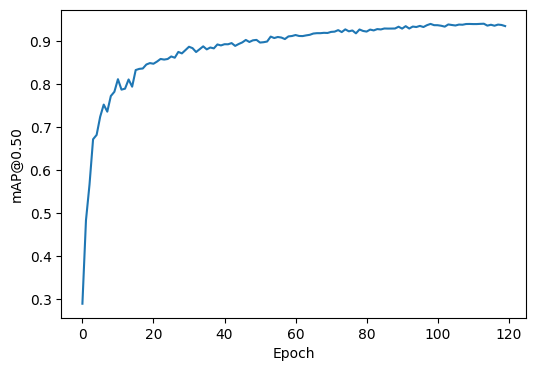

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/results.csv")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(results["metrics/mAP50(B)"])
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP@0.50")
ax.set_xticks([0,20,40,60,80,100,120])
plt.show()

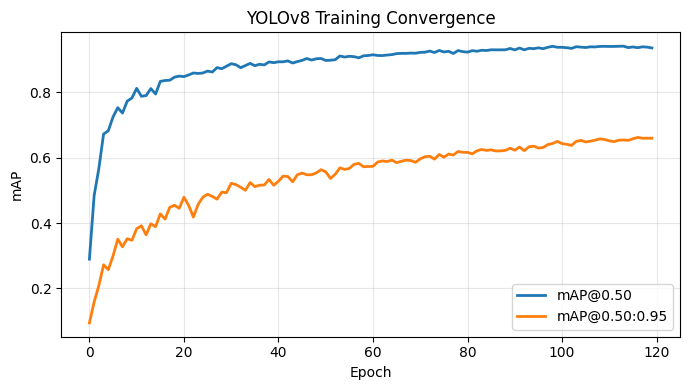

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/results.csv")

plt.figure(figsize=(7,4))

plt.plot(results["metrics/mAP50(B)"],
         linewidth=2,
         label="mAP@0.50")

plt.plot(results["metrics/mAP50-95(B)"],
         linewidth=2,
         label="mAP@0.50:0.95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv8 Training Convergence")

plt.xticks([0,20,40,60,80,100,120])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mAP_convergence.png", dpi=300)
plt.show()

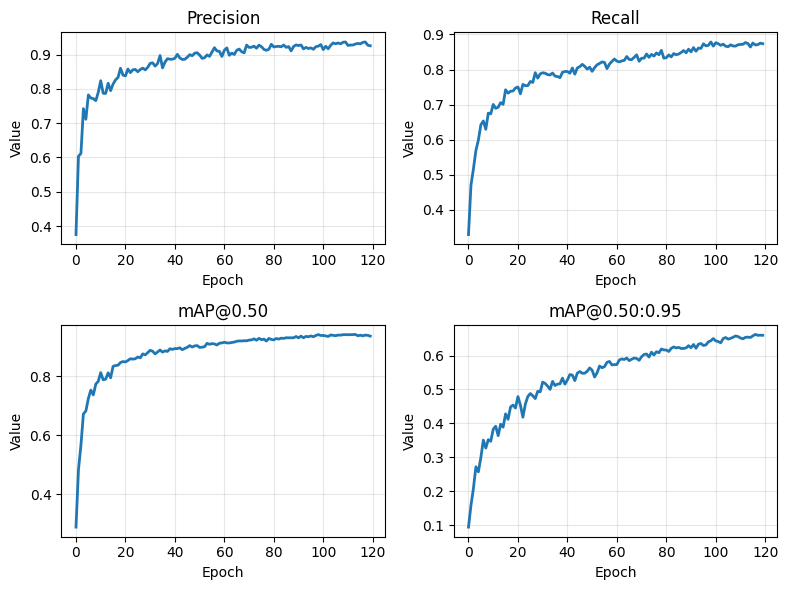

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/results.csv")

fig, axs = plt.subplots(2, 2, figsize=(8, 6))

metrics = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP@0.50"),
    ("metrics/mAP50-95(B)", "mAP@0.50:0.95")
]

for ax, (col, title) in zip(axs.ravel(), metrics):
    ax.plot(results[col], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")
    ax.set_xticks([0,20,40,60,80,100,120])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("performance_metrics.png", dpi=300)
plt.show()

PROJECT ACCORDING TO ANNULUS

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/gdrive/MyDrive/combinedold_dataset/"
    "yolo_training/suture_entry_exit_yolov8s_1024/"
    "weights/best.pt"
)

In [ ]:
datasets = [
    {
        "name": "v7",
        "images": "/content/gdrive/MyDrive/frames/v7/images",
        "xml": "/content/gdrive/MyDrive/frames/v7/v7.xml",
    },
    {
        "name": "v8",
        "images": "/content/gdrive/MyDrive/frames/v8/images",
        "xml": "/content/gdrive/MyDrive/frames/v8/v8.xml",
    },
    {
        "name": "v9",
        "images": "/content/gdrive/MyDrive/frames/v9/images",
        "xml": "/content/gdrive/MyDrive/frames/v9/v9.xml",
    },
    {
        "name": "v10",
        "images": "/content/gdrive/MyDrive/frames/v10/images",
        "xml": "/content/gdrive/MyDrive/frames/v10/v10.xml",
    },
    {
        "name": "v11",
        "images": "/content/gdrive/MyDrive/frames/v11/images",
        "xml": "/content/gdrive/MyDrive/frames/v11/v11.xml",
    },
]

In [ ]:
import xml.etree.ElementTree as ET
import numpy as np

from pathlib import Path


def parse_annulus_from_xml(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    annulus_map = {}

    for image_node in root.findall(".//image"):

        image_name = Path(
            image_node.get("name")
        ).name

        for polyline in image_node.findall("polyline"):

            label = (
                polyline.get("label", "")
                .strip()
                .lower()
            )

            if label != "annulus_line":
                continue

            points = []

            for point_text in polyline.get("points").split(";"):

                x, y = point_text.split(",")

                points.append([
                    float(x),
                    float(y),
                ])

            if len(points) >= 2:
                annulus_map[image_name] = np.array(
                    points,
                    dtype=np.float32,
                )

    return annulus_map

In [ ]:
for dataset in datasets:

    annulus_map = parse_annulus_from_xml(
        dataset["xml"]
    )

    print(
        dataset["name"],
        "images with annulus:",
        len(annulus_map),
    )

v7 images with annulus: 93
v8 images with annulus: 15
v9 images with annulus: 147
v10 images with annulus: 18
v11 images with annulus: 157


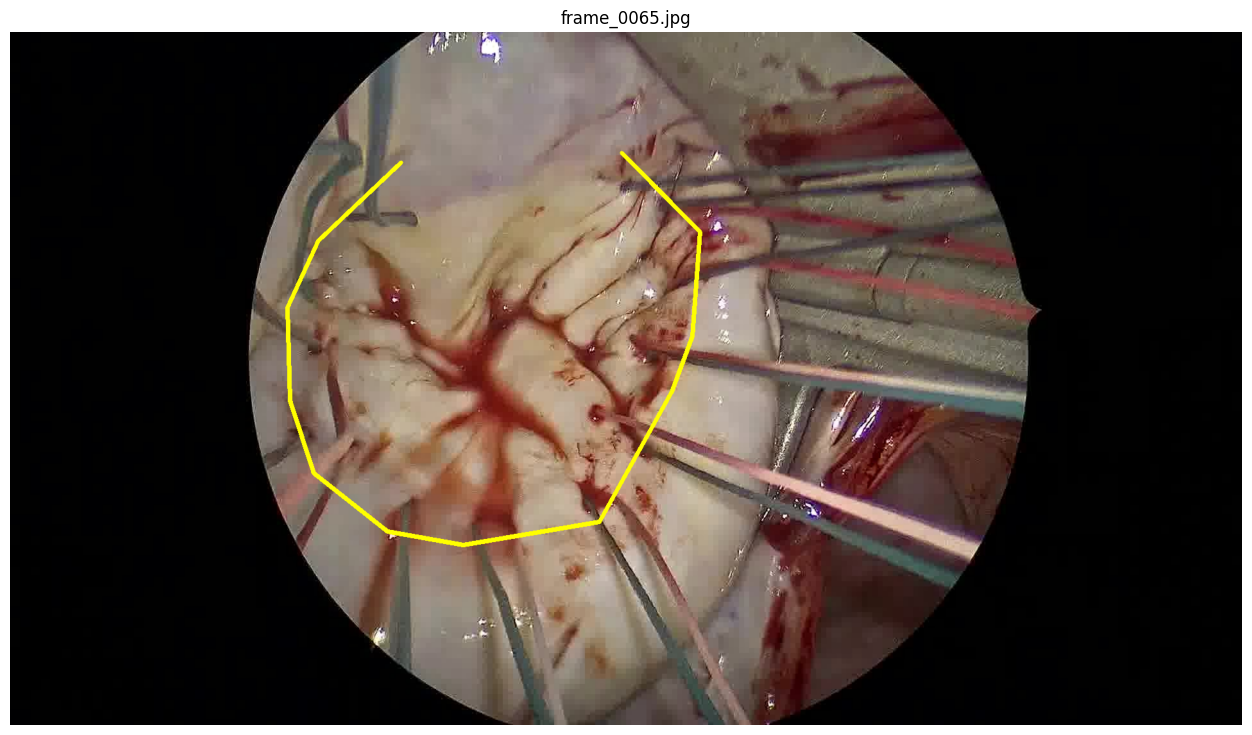

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

dataset = datasets[0]  # v7

annulus_map = parse_annulus_from_xml(
    dataset["xml"]
)

image_name = random.choice(
    list(annulus_map.keys())
)

image_path = (
    Path(dataset["images"])
    / image_name
)

image = cv2.imread(str(image_path))
annulus_points = annulus_map[image_name]

cv2.polylines(
    image,
    [annulus_points.astype(np.int32)],
    isClosed=False,
    color=(0, 255, 255),
    thickness=6,
)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB,
)

plt.figure(figsize=(16, 9))
plt.imshow(image_rgb)
plt.title(image_name)
plt.axis("off")
plt.show()

In [ ]:
result = model.predict(
    source=str(image_path),
    imgsz=1024,
    conf=0.20,
    iou=0.30,
    save=False,
)[0]

entry_points = []
exit_points = []

for box in result.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = (
        box.xyxy[0]
        .cpu()
        .numpy()
    )

    center_x = float((x1 + x2) / 2)
    center_y = float((y1 + y2) / 2)

    if class_id == 0:
        entry_points.append(
            [center_x, center_y, confidence]
        )

    elif class_id == 1:
        exit_points.append(
            [center_x, center_y, confidence]
        )

print("Entry points:", len(entry_points))
print("Exit points:", len(exit_points))


image 1/1 /content/gdrive/MyDrive/frames/v7/images/frame_0065.jpg: 576x1024 11 entry_points, 11 exit_points, 20.3ms
Speed: 4.3ms preprocess, 20.3ms inference, 1.7ms postprocess per image at shape (1, 3, 576, 1024)
Entry points: 11
Exit points: 11


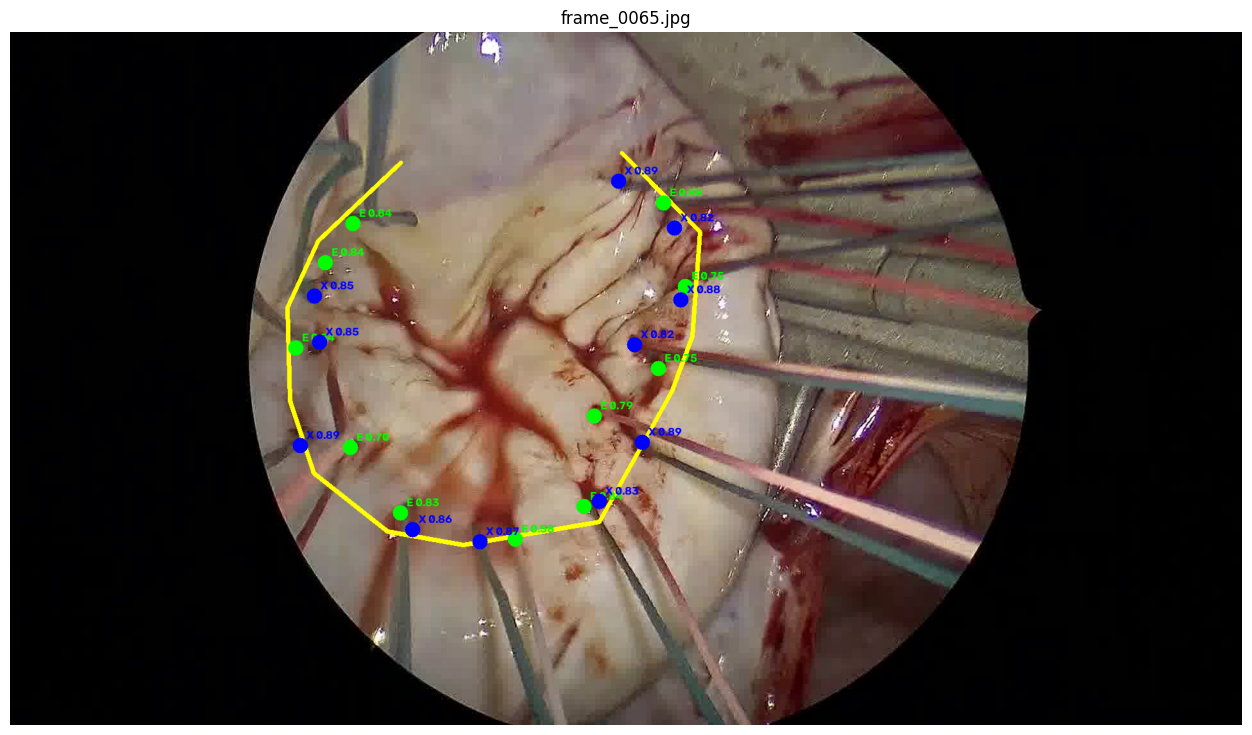

In [ ]:
image = result.orig_img.copy()

# Draw the true annotated annulus
cv2.polylines(
    image,
    [annulus_points.astype(np.int32)],
    isClosed=False,
    color=(0, 255, 255),
    thickness=6,
)

# Entry points
for x, y, confidence in entry_points:

    x = int(x)
    y = int(y)

    cv2.circle(
        image,
        (x, y),
        12,
        (0, 255, 0),
        -1,
    )

    cv2.putText(
        image,
        f"E {confidence:.2f}",
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
    )

# Exit points
for x, y, confidence in exit_points:

    x = int(x)
    y = int(y)

    cv2.circle(
        image,
        (x, y),
        12,
        (255, 0, 0),
        -1,
    )

    cv2.putText(
        image,
        f"X {confidence:.2f}",
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2,
    )

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB,
)

plt.figure(figsize=(16, 9))
plt.imshow(image_rgb)
plt.title(image_name)
plt.axis("off")
plt.show()

GAP ANALYSIS ACCORDING TO THE ANNULUS

In [ ]:
import random, cv2, os
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path

model_path = "/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/weights/best.pt"

datasets = [
    {
        "name": "v7",
        "images": "/content/gdrive/MyDrive/frames/v7/images",
        "xml": "/content/gdrive/MyDrive/frames/v7/v7.xml"
    },
    {
        "name": "v8",
        "images": "/content/gdrive/MyDrive/frames/v8/images",
        "xml": "/content/gdrive/MyDrive/frames/v8/v8.xml"
    },
     {
        "name": "v9",
        "images": "/content/gdrive/MyDrive/frames/v9/images",
        "xml": "/content/gdrive/MyDrive/frames/v9/v9.xml"
    },
    {
        "name": "v10",
        "images": "/content/gdrive/MyDrive/frames/v10/images",
        "xml": "/content/gdrive/MyDrive/frames/v10/v10.xml"
    },
    {
        "name": "v11",
        "images": "/content/gdrive/MyDrive/frames/v11/images",
        "xml": "/content/gdrive/MyDrive/frames/v11/v11.xml"
    }
]

conf_threshold = 0.30
max_point_to_annulus_dist = 70
gap_threshold_px = 100
coverage_radius_px = 40
num_images_to_show = 6


model = YOLO(model_path)


def parse_annulus_from_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    annulus_map = {}

    for image in root.findall("image"):
        img_name = Path(image.get("name")).name

        for polyline in image.findall("polyline"):
            label = polyline.get("label").lower()

            if label in ["annulus", "annulus_line"]:
                pts = []

                for p in polyline.get("points").split(";"):
                    x, y = p.split(",")
                    pts.append([float(x), float(y)])

                annulus_map[img_name] = np.array(pts)

    return annulus_map


def polyline_lengths(points):
    seg_lengths = []
    cumulative = [0]

    for i in range(len(points) - 1):
        length = np.linalg.norm(points[i + 1] - points[i])
        seg_lengths.append(length)
        cumulative.append(cumulative[-1] + length)

    return np.array(seg_lengths), np.array(cumulative)


def project_point_to_polyline(point, polyline):
    point = np.array(point)
    seg_lengths, cumulative = polyline_lengths(polyline)

    best_dist = float("inf")
    best_s = 0

    for i in range(len(polyline) - 1):
        a = polyline[i]
        b = polyline[i + 1]
        ab = b - a

        if np.dot(ab, ab) == 0:
            continue

        t = np.dot(point - a, ab) / np.dot(ab, ab)
        t = max(0, min(1, t))

        projection = a + t * ab
        dist = np.linalg.norm(point - projection)

        if dist < best_dist:
            best_dist = dist
            best_s = cumulative[i] + t * seg_lengths[i]

    return best_s, best_dist


def get_point_on_polyline(polyline, s):
    seg_lengths, cumulative = polyline_lengths(polyline)

    if s <= 0:
        return polyline[0]

    if s >= cumulative[-1]:
        return polyline[-1]

    for i in range(len(seg_lengths)):
        if cumulative[i] <= s <= cumulative[i + 1]:
            t = (s - cumulative[i]) / seg_lengths[i]
            return polyline[i] + t * (polyline[i + 1] - polyline[i])

    return polyline[-1]


def merge_intervals(intervals):
    if not intervals:
        return []

    intervals = sorted(intervals)
    merged = [list(intervals[0])]

    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    return [(a, b) for a, b in merged]


def get_gap_intervals(covered_intervals, total_len, gap_threshold):
    gaps = []
    current = 0

    for start, end in covered_intervals:
        if start - current > gap_threshold:
            gaps.append((current, start))
        current = max(current, end)

    if total_len - current > gap_threshold:
        gaps.append((current, total_len))

    return gaps


def draw_annulus_segments(img, polyline, covered_intervals, gap_intervals):
    # base annulus gray
    for i in range(len(polyline) - 1):
        p1 = tuple(polyline[i].astype(int))
        p2 = tuple(polyline[i + 1].astype(int))
        cv2.line(img, p1, p2, (180, 180, 180), 2)

    # covered green
    for start, end in covered_intervals:
        s_vals = np.linspace(start, end, 40)
        pts = [get_point_on_polyline(polyline, s) for s in s_vals]

        for i in range(len(pts) - 1):
            cv2.line(
                img,
                tuple(pts[i].astype(int)),
                tuple(pts[i + 1].astype(int)),
                (0, 255, 0),
                4
            )

    # gaps red
    for start, end in gap_intervals:
        s_vals = np.linspace(start, end, 40)
        pts = [get_point_on_polyline(polyline, s) for s in s_vals]

        for i in range(len(pts) - 1):
            cv2.line(
                img,
                tuple(pts[i].astype(int)),
                tuple(pts[i + 1].astype(int)),
                (0, 0, 255),
                4
            )


# collect images that have annulus annotation
all_items = []

for ds in datasets:
    annulus_map = parse_annulus_from_xml(ds["xml"])
    image_dir = Path(ds["images"])

    for img_name, annulus_pts in annulus_map.items():
        img_path = image_dir / img_name

        if img_path.exists():
            all_items.append((ds["name"], img_path, annulus_pts))

v7_items = []
v8_items = []
v9_items = []
v10_items = []
v11_items = []

for item in all_items:
    if item[0] == "v7":
        v7_items.append(item)
    elif item[0] == "v8":
        v8_items.append(item)
    elif item[0] == "v9":
        v9_items.append(item)
    elif item[0] == "v10":
        v10_items.append(item)
    elif item[0] == "v11":
        v11_items.append(item)

random.shuffle(v7_items)
random.shuffle(v8_items)

selected_items = []

# Show 3 random images from v7
selected_items.extend(v7_items[:3])

# Show 3 random images from v8
selected_items.extend(v8_items[:3])
selected_items.extend(v9_items[:3])
selected_items.extend(v10_items[:3])
selected_items.extend(v11_items[:3])

random.shuffle(selected_items)

print("Selected Images:")
for ds, img_path, _ in selected_items:
    print(ds, img_path.name)

print("Images selected:", len(selected_items))


for dataset_name, img_path, annulus_pts in selected_items:

    result = model.predict(
        str(img_path),
        conf=conf_threshold,
        iou=0.3,
        save=False
    )[0]

    img = result.orig_img.copy()

    raw_entry_count = 0
    raw_exit_count = 0

    filtered_entry_count = 0
    filtered_exit_count = 0

    filtered_projected_positions = []

    for box in result.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        # Raw count from YOLO
        if cls == 0:
            raw_entry_count += 1
        elif cls == 1:
            raw_exit_count += 1

        # Project detection onto annulus
        s, dist = project_point_to_polyline((cx, cy), annulus_pts)

        # Filter by distance to annulus
        if dist > max_point_to_annulus_dist:
            continue

        filtered_projected_positions.append(s)

        # Filtered count + draw
        if cls == 0:
            filtered_entry_count += 1
            cv2.circle(img, (cx, cy), 6, (0, 255, 0), -1)
            cv2.putText(img, f"E {conf:.2f}", (cx + 5, cy - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 2)

        elif cls == 1:
            filtered_exit_count += 1
            cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1)
            cv2.putText(img, f"X {conf:.2f}", (cx + 5, cy - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 2)

    total_annulus_len = polyline_lengths(annulus_pts)[1][-1]

    covered_intervals = []

    for s in filtered_projected_positions:
        start = max(0, s - coverage_radius_px)
        end = min(total_annulus_len, s + coverage_radius_px)
        covered_intervals.append((start, end))

    covered_intervals = merge_intervals(covered_intervals)

    gap_intervals = get_gap_intervals(
        covered_intervals,
        total_annulus_len,
        gap_threshold_px
    )

    covered_len = sum(end - start for start, end in covered_intervals)
    coverage_percent = (covered_len / total_annulus_len) * 100 if total_annulus_len > 0 else 0

    raw_estimated_sutures = min(raw_entry_count, raw_exit_count)
    filtered_estimated_sutures = min(filtered_entry_count, filtered_exit_count)

    draw_annulus_segments(img, annulus_pts, covered_intervals, gap_intervals)

    cv2.putText(img, f"{dataset_name} | {img_path.name}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.putText(img, f"Raw Entry: {raw_entry_count}  Exit: {raw_exit_count}", (20, 75),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.putText(img, f"Filtered Entry: {filtered_entry_count}  Exit: {filtered_exit_count}", (20, 110),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    cv2.putText(img, f"Raw Sutures: {raw_estimated_sutures} | Filtered Sutures: {filtered_estimated_sutures}", (20, 145),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    cv2.putText(img, f"Annulus Coverage: {coverage_percent:.1f}%", (20, 180),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    if len(gap_intervals) > 0:
        cv2.putText(img, f"FLAG: {len(gap_intervals)} large gap(s)", (20, 215),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    else:
        cv2.putText(img, "No large gap flagged", (20, 215),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("\n===================================")
    print("Dataset:", dataset_name)
    print("Image:", img_path.name)
    print("===================================")
    plt.figure(figsize=(18,12))
    plt.title(f"{dataset_name} - {img_path.name}", fontsize=14)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

DETECTION IN BOLD VISUALISATON

In [ ]:
import random, cv2, os
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path
from ultralytics import YOLO

# ---------------- PATHS ----------------
model_path = "/content/gdrive/MyDrive/combinedold_dataset/yolo_training/suture_entry_exit_yolov8s_1024/weights/best.pt"

datasets = [
    {
        "name": "v7",
        "images": "/content/gdrive/MyDrive/frames/v7/images",
        "xml": "/content/gdrive/MyDrive/frames/v7/v7.xml"
    },
    {
        "name": "v8",
        "images": "/content/gdrive/MyDrive/frames/v8/images",
        "xml": "/content/gdrive/MyDrive/frames/v8/v8.xml"
    },
    {
        "name": "v9",
        "images": "/content/gdrive/MyDrive/frames/v9/images",
        "xml": "/content/gdrive/MyDrive/frames/v9/v9.xml"
    },
    {
        "name": "v10",
        "images": "/content/gdrive/MyDrive/frames/v10/images",
        "xml": "/content/gdrive/MyDrive/frames/v10/v10.xml"
    },
    {
        "name": "v11",
        "images": "/content/gdrive/MyDrive/frames/v11/images",
        "xml": "/content/gdrive/MyDrive/frames/v11/v11.xml"
    }
]

conf_threshold = 0.30
max_point_to_annulus_dist = 70
gap_threshold_px = 100
coverage_radius_px = 40
num_per_dataset = 3

#  COLORS BGR
ENTRY_COLOR = (0, 255, 0)
EXIT_COLOR = (255, 0, 0)
ANNULUS_COLOR = (0, 255, 255)
GAP_COLOR = (0, 0, 255)
WHITE = (255, 255, 255)

model = YOLO(model_path)


def parse_annulus_from_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    annulus_map = {}

    for image in root.findall("image"):
        img_name = Path(image.get("name")).name

        for polyline in image.findall("polyline"):
            label = polyline.get("label").lower()

            if label in ["annulus", "annulus_line"]:
                pts = []

                for p in polyline.get("points").split(";"):
                    x, y = p.split(",")
                    pts.append([float(x), float(y)])

                annulus_map[img_name] = np.array(pts)

    return annulus_map


def polyline_lengths(points):
    seg_lengths = []
    cumulative = [0]

    for i in range(len(points) - 1):
        length = np.linalg.norm(points[i + 1] - points[i])
        seg_lengths.append(length)
        cumulative.append(cumulative[-1] + length)

    return np.array(seg_lengths), np.array(cumulative)


def project_point_to_polyline(point, polyline):
    point = np.array(point)
    seg_lengths, cumulative = polyline_lengths(polyline)

    best_dist = float("inf")
    best_s = 0

    for i in range(len(polyline) - 1):
        a = polyline[i]
        b = polyline[i + 1]
        ab = b - a

        if np.dot(ab, ab) == 0:
            continue

        t = np.dot(point - a, ab) / np.dot(ab, ab)
        t = max(0, min(1, t))

        projection = a + t * ab
        dist = np.linalg.norm(point - projection)

        if dist < best_dist:
            best_dist = dist
            best_s = cumulative[i] + t * seg_lengths[i]

    return best_s, best_dist


def get_point_on_polyline(polyline, s):
    seg_lengths, cumulative = polyline_lengths(polyline)

    if s <= 0:
        return polyline[0]

    if s >= cumulative[-1]:
        return polyline[-1]

    for i in range(len(seg_lengths)):
        if cumulative[i] <= s <= cumulative[i + 1]:
            t = (s - cumulative[i]) / seg_lengths[i]
            return polyline[i] + t * (polyline[i + 1] - polyline[i])

    return polyline[-1]


def merge_intervals(intervals):
    if not intervals:
        return []

    intervals = sorted(intervals)
    merged = [list(intervals[0])]

    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    return [(a, b) for a, b in merged]


def get_gap_intervals(covered_intervals, total_len, gap_threshold):
    gaps = []
    current = 0

    for start, end in covered_intervals:
        if start - current > gap_threshold:
            gaps.append((current, start))

        current = max(current, end)

    if total_len - current > gap_threshold:
        gaps.append((current, total_len))

    return gaps


def draw_annulus_segments(img, polyline, covered_intervals, gap_intervals):
    # Base annulus = yellow
    for i in range(len(polyline) - 1):
        p1 = tuple(polyline[i].astype(int))
        p2 = tuple(polyline[i + 1].astype(int))
        cv2.line(img, p1, p2, ANNULUS_COLOR, 5)

    # Covered annulus = yellow
    for start, end in covered_intervals:
        s_vals = np.linspace(start, end, 50)
        pts = [get_point_on_polyline(polyline, s) for s in s_vals]

        for i in range(len(pts) - 1):
            cv2.line(
                img,
                tuple(pts[i].astype(int)),
                tuple(pts[i + 1].astype(int)),
                ANNULUS_COLOR,
                7
            )

    # Gap regions = red
    for start, end in gap_intervals:
        s_vals = np.linspace(start, end, 50)
        pts = [get_point_on_polyline(polyline, s) for s in s_vals]

        for i in range(len(pts) - 1):
            cv2.line(
                img,
                tuple(pts[i].astype(int)),
                tuple(pts[i + 1].astype(int)),
                GAP_COLOR,
                9
            )


def draw_entry_exit(img, cx, cy, cls, conf):
    if cls == 0:
        # Entry = green
        cv2.circle(img, (cx, cy), 16, ENTRY_COLOR, -1)
        cv2.circle(img, (cx, cy), 20, WHITE, 3)

        cv2.putText(
            img,
            "E",
            (cx + 20, cy - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            ENTRY_COLOR,
            4
        )

    elif cls == 1:
        # Exit = blue
        cv2.circle(img, (cx, cy), 16, EXIT_COLOR, -1)
        cv2.circle(img, (cx, cy), 20, WHITE, 3)

        cv2.putText(
            img,
            "X",
            (cx + 20, cy - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            EXIT_COLOR,
            4
        )


#  COLLECT IMAGES WITH ANNULUS
all_items = []

for ds in datasets:
    xml_path = Path(ds["xml"])
    image_dir = Path(ds["images"])

    if not xml_path.exists():
        print("Missing XML:", xml_path)
        continue

    if not image_dir.exists():
        print("Missing image folder:", image_dir)
        continue

    annulus_map = parse_annulus_from_xml(xml_path)

    for img_name, annulus_pts in annulus_map.items():
        img_path = image_dir / img_name

        if img_path.exists():
            all_items.append((ds["name"], img_path, annulus_pts))

print("Total images with annulus:", len(all_items))


#  SELECT IMAGES FROM EACH DATASET
items_by_dataset = {}

for item in all_items:
    dataset_name = item[0]

    if dataset_name not in items_by_dataset:
        items_by_dataset[dataset_name] = []

    items_by_dataset[dataset_name].append(item)

selected_items = []

for dataset_name, items in items_by_dataset.items():
    random.shuffle(items)
    selected_items.extend(items[:num_per_dataset])

random.shuffle(selected_items)

print("Selected Images:")
for ds, img_path, _ in selected_items:
    print(ds, img_path.name)

print("Images selected:", len(selected_items))


# RUN ANALYSIS
for dataset_name, img_path, annulus_pts in selected_items:

    result = model.predict(
        str(img_path),
        conf=conf_threshold,
        iou=0.3,
        save=False
    )[0]

    img = result.orig_img.copy()

    raw_entry_count = 0
    raw_exit_count = 0

    filtered_entry_count = 0
    filtered_exit_count = 0

    filtered_projected_positions = []

    for box in result.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        # Raw count from YOLO
        if cls == 0:
            raw_entry_count += 1
        elif cls == 1:
            raw_exit_count += 1


        s, dist = project_point_to_polyline((cx, cy), annulus_pts)


        if dist > max_point_to_annulus_dist:
            continue

        filtered_projected_positions.append(s)


        if cls == 0:
            filtered_entry_count += 1
        elif cls == 1:
            filtered_exit_count += 1

        draw_entry_exit(img, cx, cy, cls, conf)

    total_annulus_len = polyline_lengths(annulus_pts)[1][-1]

    covered_intervals = []

    for s in filtered_projected_positions:
        start = max(0, s - coverage_radius_px)
        end = min(total_annulus_len, s + coverage_radius_px)
        covered_intervals.append((start, end))

    covered_intervals = merge_intervals(covered_intervals)

    gap_intervals = get_gap_intervals(
        covered_intervals,
        total_annulus_len,
        gap_threshold_px
    )

    covered_len = sum(end - start for start, end in covered_intervals)

    coverage_percent = (
        (covered_len / total_annulus_len) * 100
        if total_annulus_len > 0
        else 0
    )

    raw_estimated_sutures = min(raw_entry_count, raw_exit_count)
    filtered_estimated_sutures = min(filtered_entry_count, filtered_exit_count)

    draw_annulus_segments(
        img,
        annulus_pts,
        covered_intervals,
        gap_intervals
    )

    # DISPLAY TEXT
    cv2.putText(
        img,
        f"{dataset_name} | {img_path.name}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        WHITE,
        3
    )

    cv2.putText(
        img,
        f"Raw Entry: {raw_entry_count}   Exit: {raw_exit_count}",
        (20, 85),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        WHITE,
        3
    )

    cv2.putText(
        img,
        f"Filtered Entry: {filtered_entry_count}   Exit: {filtered_exit_count}",
        (20, 125),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        ANNULUS_COLOR,
        3
    )

    cv2.putText(
        img,
        f"Raw Sutures: {raw_estimated_sutures} | Filtered Sutures: {filtered_estimated_sutures}",
        (20, 165),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        ANNULUS_COLOR,
        3
    )

    cv2.putText(
        img,
        f"Annulus Coverage: {coverage_percent:.1f}%",
        (20, 205),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        ANNULUS_COLOR,
        3
    )

    if len(gap_intervals) > 0:
        cv2.putText(
            img,
            f"FLAG: {len(gap_intervals)} large gap(s)",
            (20, 245),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.85,
            GAP_COLOR,
            3
        )
    else:
        cv2.putText(
            img,
            "No large gap flagged",
            (20, 245),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.85,
            ENTRY_COLOR,
            3
        )

    #  LEGEND
    legend_y = img.shape[0] - 35

    cv2.putText(img, "Annulus", (20, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, ANNULUS_COLOR, 3)

    cv2.putText(img, "Entry", (180, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, ENTRY_COLOR, 3)

    cv2.putText(img, "Exit", (310, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, EXIT_COLOR, 3)

    cv2.putText(img, "Gap", (430, legend_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, GAP_COLOR, 3)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("\n===================================")
    print("Dataset:", dataset_name)
    print("Image:", img_path.name)
    print("Raw Entry:", raw_entry_count)
    print("Raw Exit:", raw_exit_count)
    print("Filtered Entry:", filtered_entry_count)
    print("Filtered Exit:", filtered_exit_count)
    print("Coverage:", round(coverage_percent, 1), "%")
    print("Gaps:", len(gap_intervals))
    print("===================================")

    plt.figure(figsize=(18, 12))
    plt.title(f"{dataset_name} - {img_path.name}", fontsize=16)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.